# fig1

Removed no burn in
Removed no burn in
Removed no burn in
<class 'numpy.float64'> 323.0
<class 'numpy.float64'> 990.0
984.3439529609408 997.4398911098166 6.547969074437901 1D
Removed no burn in
[0.27853363 0.01582135]
0.2785336313715502 0.01582134932531795
989.3526043512614 990.2880228769275 0.4677092628330115


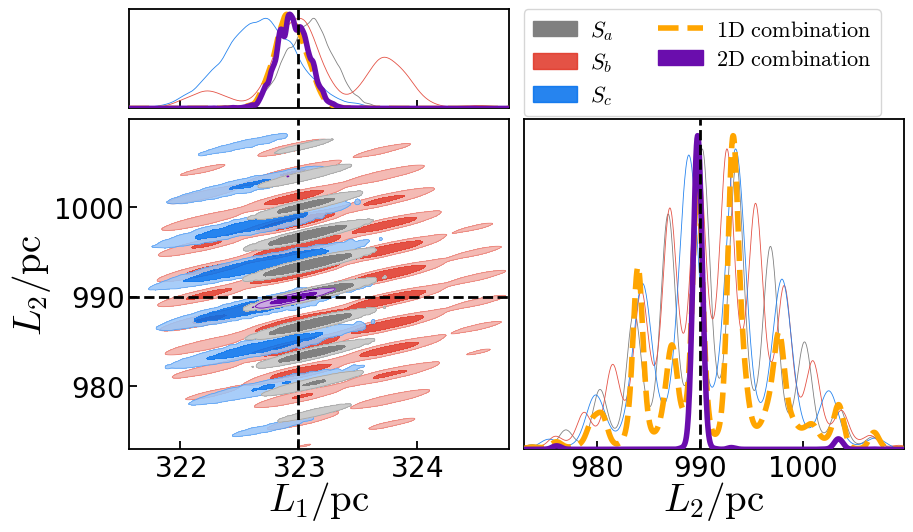

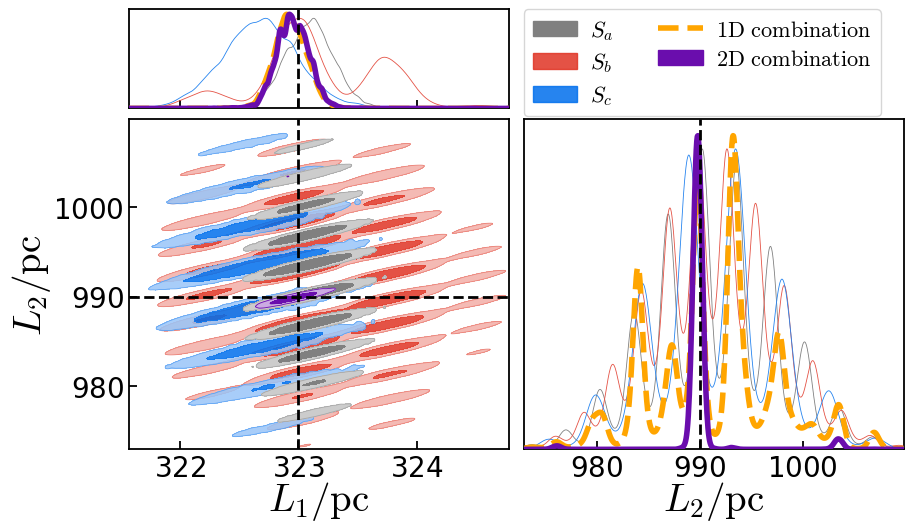

0

In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.font_manager import FontProperties
from scipy.stats import norm as stats_norm
from scipy.interpolate import RegularGridInterpolator
from getdist import MCSamples, plots
import logging
# from qcosmc.FigStyle import qstyle
# from qcosmc import FigStyle

logging.disable(logging.CRITICAL)
# FigStyle.qstyle(1)
mpl.rcParams.update({'font.size': 20, 'axes.labelsize': 30, 'xtick.labelsize': 30, 'ytick.labelsize': 30, 'legend.fontsize': 30})
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
mpl.rcParams['text.usetex'] = False


pulsar_file = np.loadtxt('data/pulsar/pulsar_ra_dec_dist_85.txt')
dp_err = pulsar_file[:, 3] * 1e6   # 85 文件中 dp_err 在第 3 列（87 文件在第 4 列）
alphap = pulsar_file[:, 0] / 180 * np.pi
deltap = pulsar_file[:, 1] / 180 * np.pi
dp = pulsar_file[:, 2] * 1e6



def sample_from_2d_grid(x, y, pdf, n_samples=30000, jitter=True, rng=None):
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    rng = np.random.default_rng() if rng is None else rng
    pmass = (pdf * dx * dy).ravel()
    pmass[pmass < 1e-15] = 0.0
    pmass /= pmass.sum()
    idx = rng.choice(pmass.size, size=n_samples, p=pmass)
    H, W = pdf.shape
    iy, ix = np.divmod(idx, W)
    if jitter:
        jx = rng.random(n_samples)
        jy = rng.random(n_samples)
    else:
        jx = jy = 0.5
    xs = x[ix] + (jx - 0.5) * dx
    ys = y[iy] + (jy - 0.5) * dy
    return np.column_stack([xs, ys])


def plot_2p_custom(samples, xpar="dp1", ypar="dp2", filled=True, legend_labels=None, fig_width=10, top_height=0.45, hgap=0.05, wgap=0.05, hide_top_ticks=True, legend_in_blank=True):
    g = plots.getSubplotPlotter()
    g.settings.fig_width_inch = fig_width
    g.make_figure(nx=7, ny=4)
    fig = g.fig
    fig.clf()
    gs = GridSpec(2, 2, figure=fig, height_ratios=[top_height, 1.0], hspace=hgap, wspace=wgap)
    ax_x = fig.add_subplot(gs[0, 0])
    ax_2d = fig.add_subplot(gs[1, 0])
    ax_y = fig.add_subplot(gs[1, 1])
    ax_blank = fig.add_subplot(gs[0, 1])
    ax_blank.set_xticks([])
    ax_blank.set_yticks([])
    for sp in ax_blank.spines.values():
        sp.set_visible(False)
    g.subplots = [[ax_x, ax_blank], [ax_2d, ax_y]]
    g.plot_1d(samples, xpar, ax=ax_x, label_right=False, no_ylabel=True, no_ytick=True)
    g.plot_2d(samples, xpar, ypar, filled=filled, ax=ax_2d)
    g.plot_1d(samples, ypar, ax=ax_y, label_right=False)
    colors = ['#808080', '#e45245', '#2684ef']
    n = len(samples)
    for i, ln in enumerate(ax_x.lines[-n:]):
        ln.set_color(colors[i % len(colors)])
    for i, ln in enumerate(ax_y.lines[-n:]):
        ln.set_color(colors[i % len(colors)])

    def reorder_getdist_artists_by_group(ax, n_groups=3, order=(1, 2, 0), z_base=10, z_step=10):
        cols = list(ax.collections)
        lns = list(ax.lines)
        if len(cols) >= n_groups:
            k = len(cols) // n_groups
            groups = [cols[i * k:(i + 1) * k] for i in range(n_groups - 1)]
            groups.append(cols[(n_groups - 1) * k:])
            for rank, gi in enumerate(order):
                for a in groups[gi]:
                    a.set_zorder(z_base + rank * z_step)
        if len(lns) >= n_groups:
            k = len(lns) // n_groups
            groups = [lns[i * k:(i + 1) * k] for i in range(n_groups - 1)]
            groups.append(lns[(n_groups - 1) * k:])
            for rank, gi in enumerate(order):
                for a in groups[gi]:
                    a.set_zorder(z_base + rank * z_step + 1)
        ax.figure.canvas.draw_idle()

    reorder_getdist_artists_by_group(ax_2d, n_groups=3, order=(1, 2, 0))
    spine_lw = 1.3
    tick_w = 1.3
    tick_len = 6
    for ax in (ax_x, ax_2d, ax_y):
        for sp in ax.spines.values():
            sp.set_linewidth(spine_lw)
        ax.tick_params(width=tick_w, length=tick_len)
    if hide_top_ticks:
        ax_x.tick_params(axis='x', which='both', labelbottom=False)
        ax_x.tick_params(axis='y', which='both', labelleft=False)
    ax_x.set_xlabel("")
    ax_x.set_ylabel("")
    ax_x.set_title("")
    for t in list(ax_x.texts):
        t.remove()
    g.settings.legend_fontsize = 16
    if legend_labels is not None:
        target_ax = ax_blank if legend_in_blank else ax_2d
        g.add_legend(ax=target_ax, legend_labels=legend_labels, frameon=False, legend_loc="upper left")
    return fig, ax_x, ax_y, ax_2d, ax_blank


def add_joint_overlay(ax_x, ax_y, ax_2d, xg, yg, joint1_1d, joint2_1d, color='orange', lw=4, alpha_2s=0.07, alpha_1s=0.07, legend_ax=None, legend_fontsize=15, legend_label="1D combination"):
    ymax_x = ax_x.get_ylim()[1]
    ymax_y = ax_y.get_ylim()[1]
    j1 = joint1_1d / np.max(joint1_1d) if np.max(joint1_1d) > 0 else joint1_1d
    j2 = joint2_1d / np.max(joint2_1d) if np.max(joint2_1d) > 0 else joint2_1d
    line_y, = ax_y.plot(yg, j2 * 0.95 * ymax_y, ls='--', lw=lw, color=color, zorder=80, label=legend_label)
    line_x, = ax_x.plot(xg, j1 * 0.95 * ymax_x, ls='--', lw=lw, color=color, zorder=80, label=legend_label)
    x = np.asarray(yg)
    p = np.clip(np.asarray(j2), 0, None)
    p = p / np.trapz(p, x)
    cdf = np.cumsum(p * np.gradient(x))
    cdf = cdf / cdf[-1]
    q16 = np.interp(0.16, cdf, x)
    q84 = np.interp(0.84, cdf, x)
    half_width_1sigma = 0.5 * (q84 - q16)
    # print(q16, q84, half_width_1sigma, '1D')

    def cdf_from_pdf(grid, pdf):
        pdf = np.maximum(pdf, 0.0)
        area = np.trapz(pdf, grid)
        if area <= 0:
            return np.linspace(0, 1, len(grid))
        pdf = pdf / area
        cdf = np.concatenate([[0.0], np.cumsum(0.5 * (pdf[:-1] + pdf[1:]) * np.diff(grid))])
        cdf = cdf / cdf[-1]
        return cdf

    cdf1 = cdf_from_pdf(xg, joint1_1d)
    cdf2 = cdf_from_pdf(yg, joint2_1d)
    x_1lo, x_1hi = np.interp([0.15865, 0.84135], cdf1, xg)
    x_2lo, x_2hi = np.interp([0.02275, 0.97725], cdf1, xg)
    y_1lo, y_1hi = np.interp([0.15865, 0.84135], cdf2, yg)
    y_2lo, y_2hi = np.interp([0.02275, 0.97725], cdf2, yg)
    if legend_ax is None:
        legend_ax = ax_2d
    handles, labels = [], []
    old = legend_ax.get_legend()
    if old is not None:
        handles = list(old.legend_handles)
        labels = [t.get_text() for t in old.get_texts()]
        old.remove()
    handles.append(line_y)
    labels.append(legend_label)
    legend_ax.legend(handles=handles, labels=labels, loc="upper left", frameon=True, fontsize=legend_fontsize, ncol=1, labelspacing=0.4, handletextpad=0.6, borderaxespad=0.0)
    return (x_1lo, x_1hi, x_2lo, x_2hi, y_1lo, y_1hi, y_2lo, y_2hi)


def draw_joint_ms_on_axes(joint_MS, ax_x, ax_y, ax_2d, xpar="dp1", ypar="dp2", color="#6A0DAD", filled=True, lw=4, z2d_line=50, z2d_fill=40, z1d=45, legend_label=None, legend_fontsize=10, legend_ax=None):
    d2 = joint_MS.get2DDensity(xpar, ypar)
    X, Y = np.meshgrid(d2.x, d2.y)
    try:
        levels = d2.getContourLevels()
    except Exception:
        levels = np.linspace(d2.P.max() * 0.2, d2.P.max() * 0.9, 2)
    lev = np.array(levels)
    # print(lev)
    l1, l2 = lev.max(), lev.min()
    # print(l1, l2)
    l1 = l1 + 0.07
    l2 = l2 + 0.02

    def lighten_color(color, amount=0.5):
        import matplotlib.colors as mc
        c = np.array(mc.to_rgb(color))
        return tuple(c + (1.0 - c) * amount)

    c_2s = lighten_color(color, 0.65)
    c_1s = color
    ax_2d.contourf(X, Y, d2.P, levels=[l2, l1, d2.P.max()], colors=[c_2s, c_1s], zorder=120)
    ax_2d.contour(X, Y, d2.P, levels=[l2, l1], colors=color, linewidths=0.6, zorder=121)
    d1x = joint_MS.get1DDensity(xpar)
    ymax_x = ax_x.get_ylim()[1]
    Px = d1x.P / np.max(d1x.P) if np.max(d1x.P) > 0 else d1x.P
    ax_x.plot(d1x.x, Px * 0.95 * ymax_x, color=color, lw=lw, zorder=80)
    d1y = joint_MS.get1DDensity(ypar)
    ymax_y = ax_y.get_ylim()[1]
    Py = d1y.P / np.max(d1y.P) if np.max(d1y.P) > 0 else d1y.P
    ax_y.plot(d1y.x, Py * 0.95 * ymax_y, color=color, lw=lw, zorder=80)
    x = np.asarray(d1y.x)
    p = np.clip(np.asarray(Py), 0, None)
    p = p / np.trapz(p, x)
    cdf = np.cumsum(p * np.gradient(x))
    cdf = cdf / cdf[-1]
    q16 = np.interp(0.16, cdf, x)
    q84 = np.interp(0.84, cdf, x)
    half_width_1sigma = 0.5 * (q84 - q16)
    print(q16, q84, half_width_1sigma)
    if legend_label is not None:
        if legend_ax is None:
            legend_ax = ax_2d
        patch = mpatches.Patch(facecolor=color, edgecolor=color, label=legend_label, alpha=1)
        handles, labels = [], []
        old = legend_ax.get_legend()
        if old is not None:
            handles = list(old.legend_handles)
            labels = [t.get_text() for t in old.get_texts()]
            old.remove()
        handles.append(patch)
        labels.append(legend_label)
        col1_h, col1_l, col2_h, col2_l = [], [], [], []
        for h, l in zip(handles, labels):
            if ("+" in l) or l.strip().startswith("1D"):
                col2_h.append(h)
                col2_l.append(l)
            else:
                col1_h.append(h)
                col1_l.append(l)
        handles = col1_h + col2_h
        labels = col1_l + col2_l
        fp = FontProperties(size=legend_fontsize)
        legend_ax.legend(handles=handles, labels=labels, loc="upper left", frameon=True, prop=fp, ncol=2, labelspacing=0.4, handletextpad=0.6, borderaxespad=0.0)
    return None


def plot_results(u, ss, pi_1, pi_2, tspan, Gpc, seed):
    dperr1 = dp_err[pi_1] / (tspan ** 0.5) * 5e-8 / 2e-8
    dperr2 = dp_err[pi_2] / (tspan ** 0.5) * 5e-8 / 2e-8
    names = ["dp1", "dp2"]
    labels = ["dp1", "dp2"]
    smooth_scale = 0.15
    x_min = dp[pi_1] - 5 * dperr1
    x_max = dp[pi_1] + 5 * dperr1
    y_min = dp[pi_2] - 5 * dperr2
    y_max = dp[pi_2] + 5 * dperr2
    xg = np.linspace(x_min, x_max, 2048)
    yg = np.linspace(y_min, y_max, 2048)
    Yg, Xg = np.meshgrid(yg, xg, indexing='ij')
    np.random.seed(seed)
    loc_sample1 = np.random.normal(dp[pi_1], dperr1)
    np.random.seed(seed + 5)
    loc_sample2 = np.random.normal(dp[pi_2], dperr2)
    prior_x = stats_norm.pdf(xg, loc=loc_sample1, scale=dperr1)
    prior_y = stats_norm.pdf(yg, loc=loc_sample2, scale=dperr2)
    PRIOR = np.outer(prior_y, prior_x)
    PRIOR_safe = PRIOR + 1e-300
    pdf_list = []
    mcs_list = []
    post1_1d = []
    post2_1d = []
    for s in ss:
        fname = f'dp_samples/samples_s{s}_{pi_1}_{pi_2}_sigma_5e-08_Tspan_{tspan}.npy'
        data = np.load(fname)[:, [0, 1]] * 1e6
        w_prior_1d = np.exp(-0.5 * (((data[:, 0] - loc_sample1) / dperr1) ** 2 + ((data[:, 1] - loc_sample2) / dperr2) ** 2)).astype(float)
        ms = MCSamples(samples=data, names=names, labels=labels, weights=w_prior_1d, label=f's{s}')
        ms.updateSettings({'smooth_scale_2D': 0.06, 'smooth_scale_1D': 0.12, "fine_bins_2D": 1200})
        mcs_list.append(ms)
        d_i = ms.get2DDensity("dp1", "dp2", resolution=2048, ranges={"dp1": [x_min, x_max], "dp2": [y_min, y_max]})
        f_interp = RegularGridInterpolator((d_i.y, d_i.x), d_i.P, bounds_error=False, fill_value=0.0)
        pts = np.column_stack([Yg.ravel(), Xg.ravel()])
        pdf_list.append(f_interp(pts).reshape(len(yg), len(xg)))
        d1 = ms.get1DDensity("dp1", ranges=[x_min, x_max])
        Pi = np.interp(xg, d1.x, d1.P, left=0.0, right=0.0)
        Pi /= np.trapz(Pi, xg)
        post1_1d.append(Pi)
        d2 = ms.get1DDensity("dp2", ranges=[y_min, y_max])
        Pi = np.interp(yg, d2.x, d2.P, left=0.0, right=0.0)
        Pi /= np.trapz(Pi, yg)
        post2_1d.append(Pi)
    N = len(post1_1d)
    prod_post = np.ones_like(xg)
    for Pi in post1_1d:
        prod_post *= np.maximum(Pi, 1e-300)
    joint1_1d = prod_post / (np.maximum(prior_x, 1e-300) ** (N - 1))
    Z = np.trapz(joint1_1d, xg)
    joint1_1d = joint1_1d / Z if Z > 0 else np.zeros_like(joint1_1d)
    N = len(post2_1d)
    prod_post = np.ones_like(yg)
    for Pi in post2_1d:
        prod_post *= np.maximum(Pi, 1e-300)
    joint2_1d = prod_post / (np.maximum(prior_y, 1e-300) ** (N - 1))
    Z = np.trapz(joint2_1d, yg)
    joint2_1d = joint2_1d / Z if Z > 0 else np.zeros_like(joint2_1d)
    n = len(pdf_list)
    pdf_joint = np.ones_like(PRIOR_safe)
    for P in pdf_list:
        pdf_joint *= P
    if n > 1:
        pdf_joint /= (PRIOR_safe ** (n - 1))
    dx = float(np.mean(np.diff(xg)))
    dy = float(np.mean(np.diff(yg)))
    norm_factor = pdf_joint.sum() * dx * dy
    if norm_factor > 0:
        pdf_joint /= norm_factor
    # print(type(dp[pi_1]), dp[pi_1])
    # print(type(dp[pi_2]), dp[pi_2])
    fig, ax_x, ax_y, ax_2d, ax_blank = plot_2p_custom(mcs_list, xpar="dp1", ypar="dp2", filled=True, legend_labels=[r'${S}_a$', r'${S}_b$', r'${S}_c$'], fig_width=10, top_height=0.3, hgap=0.05, wgap=0.04)
    for ax in (ax_x, ax_y, ax_2d):
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.tick_params(axis='both', which='minor', labelsize=18)
    ax_x.axvline(dp[pi_1], linestyle='--', linewidth=2, color='k', zorder=140)
    ax_y.axvline(dp[pi_2], linestyle='--', linewidth=2, color='k', zorder=140)
    ax_2d.axvline(dp[pi_1], linestyle='--', linewidth=2, color='k', zorder=140)
    ax_2d.axhline(dp[pi_2], linestyle='--', linewidth=2, color='k', zorder=140)
    ax_2d.set_xlabel(r"$L_{1}/\mathrm{pc}$", fontsize=28, labelpad=20)
    ax_2d.set_ylabel(r"$L_{2}/\mathrm{pc}$", fontsize=28, labelpad=0)
    ax_y.set_xlabel(r"$L_{2}/\mathrm{pc}$", fontsize=28, labelpad=20)
    ax_x.set_xlim(loc_sample1 - 3 * dperr1, loc_sample1 + 3 * dperr1)
    ax_y.set_xlim(loc_sample2 - 3 * dperr2, loc_sample2 + 3 * dperr2)
    ax_2d.set_xlim(loc_sample1 - 3 * dperr1, loc_sample1 + 3 * dperr1)
    ax_2d.set_ylim(loc_sample2 - 3 * dperr2, loc_sample2 + 3 * dperr2)
    add_joint_overlay(ax_x, ax_y, ax_2d, xg, yg, joint1_1d, joint2_1d, legend_ax=ax_blank, legend_label=r'$\mathrm{1D\ combination}$')
    joint_samples = sample_from_2d_grid(xg, yg, pdf_joint, n_samples=1000000, jitter=True)
    joint_MS = MCSamples(samples=joint_samples, names=names, labels=labels)
    joint_MS.updateSettings({'smooth_scale_2D': 0.06, 'smooth_scale_1D': 0.06, "fine_bins_2D": 1200})
    draw_joint_ms_on_axes(joint_MS, ax_x, ax_y, ax_2d, legend_label=r'$\mathrm{2D\ combination}$', legend_fontsize=16, legend_ax=ax_blank)
    fig.savefig('./fig1.pdf', bbox_inches='tight', pad_inches=0.03, dpi=1200)
    plt.show()
    return 0


plot_results(3, [13, 45, 78], 0, 1, 2, 1.0, 72)

# fig2

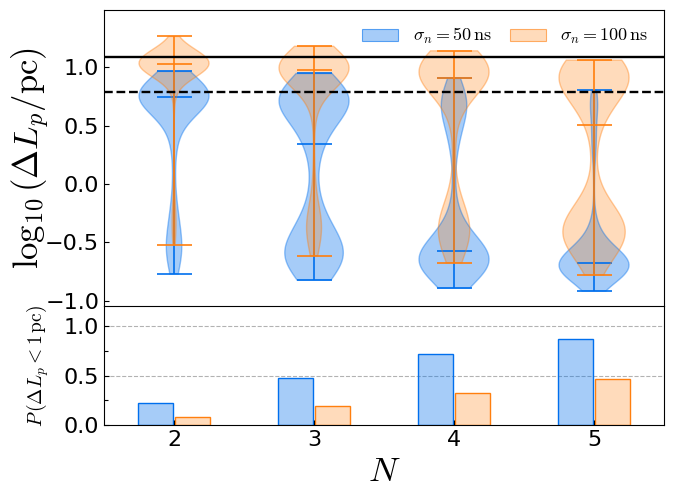

In [8]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, PathPatch
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec
# from qcosmc import FigStyle
# FigStyle.qstyle(1)

# ====== 全局设置 ======
mpl.rcParams.update({'text.usetex': False, 'patch.force_edgecolor': True, 'patch.antialiased': True})
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'cm', 'xtick.direction': 'in', 'ytick.direction': 'in', 'font.size': 20, 'axes.labelsize': 25, 'axes.titlesize': 26, 'xtick.labelsize': 16, 'ytick.labelsize': 16})

tspan      = 2
COLORS     = ['#006fed', '#ff7f0e']
ALPHAS     = [0.35, 0.28]
EDGE_ALPHA = 0.4
POSITIONS  = [1, 2, 3, 4]
XTICKS     = [1, 2, 3, 4]
XTLABELS   = [2, 3, 4, 5]
THRESHOLD  = 0.0

dp = np.loadtxt('data/pulsar/pulsar_ra_dec_dist_85.txt')

# ====== 批量加载数据 ======
def load_data(prefix, suffix, ns=(2, 3, 4, 5)):
    return [np.log10(np.loadtxt(f'results/{prefix}_t2_1.0Gpc_{n}s{suffix}.txt')) for n in ns]

data0     = load_data('dp0post', '')
data1     = load_data('dp1post', '')
data7     = load_data('dp7post', '')
data0_100 = load_data('dp0post', '_1e-07')
data1_100 = load_data('dp1post', '_1e-07')
data7_100 = load_data('dp7post', '_1e-07')

# ====== 小提琴绘制函数 ======
def draw_violins(ax, data50, data100, yref, positions):
    for data_list, face_color, alpha in zip((data50, data100), COLORS, ALPHAS):
        vp = ax.violinplot(data_list, showmeans=False, showextrema=True, showmedians=True, widths=0.5, positions=positions)
        for body in vp['bodies'][:]:
            path = body.get_paths()[0]
            z = body.get_zorder()
            ax.add_patch(PathPatch(path, facecolor=face_color, edgecolor='none', lw=0, alpha=alpha, zorder=z))
            ax.add_patch(PathPatch(path, facecolor='none', edgecolor=face_color, lw=1, alpha=EDGE_ALPHA, zorder=z + 1))
            body.remove()
        for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor(face_color)
                vp[part].set_linewidth(1.2)
    ax.axhline(np.log10(yref * 1e6), color='k', lw=1.7, ls='--')
    ax.axhline(np.log10(yref * 1e6 * 2), color='k', lw=1.7, ls='-')

# ====== 创建图 ======
fig = plt.figure(figsize=(7, 5))
gs = GridSpec(2, 1, figure=fig, height_ratios=[5.5, 2.2], hspace=0, left=0.16, right=0.96, top=0.95, bottom=0.12)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1])

yref = dp[1, 3] * 5e-08 / 2e-08 / (tspan ** 0.5)   # col 4 → col 3

# ====== 上图：小提琴 ======
draw_violins(ax_top, data1[:4], data1_100[:4], yref, POSITIONS)
ax_top.set_xlim(0.5, 4.5)
ax_top.set_ylim(-1.05, 1.49)
ax_top.set_xticks(XTICKS)
ax_top.set_xticklabels([])
ax_top.tick_params(bottom=False)
ax_top.spines['bottom'].set_visible(False)
ax_top.set_ylabel(r"$\log_{10}(\Delta L_{p}/\mathrm{pc})$", labelpad=-5)
ax_top.legend(handles=[Patch(facecolor=to_rgba(c, a), edgecolor=to_rgba(c, 0.6), linewidth=0.8, label=lab) for c, a, lab in zip(COLORS, ALPHAS, [r'$\sigma_n = 50\,\mathrm{ns}$', r'$\sigma_n = 100\,\mathrm{ns}$'])], loc='upper right', ncol=2, frameon=True, framealpha=0, fontsize=13, columnspacing=1)

# ====== 下图：Fraction 柱状图 ======
bar_width = 0.25
gap = 0.0095
offsets = [-(bar_width + gap) / 2, (bar_width + gap) / 2]

for data_list, color, alpha, offset in zip([data1[:4], data1_100[:4]], COLORS, ALPHAS, offsets):
    fracs = [np.mean(np.array(d) < THRESHOLD) for d in data_list]
    xpos = [p + offset for p in POSITIONS]
    bars = ax_bot.bar(xpos, fracs, width=bar_width, color=color, linewidth=1.0)
    for bar in bars:
        bar.set_facecolor(to_rgba(color, alpha))
        bar.set_edgecolor(to_rgba(color, 1))

ax_bot.set_xlim(0.5, 4.5)
ax_bot.set_xticks(XTICKS)
ax_bot.set_xticklabels(XTLABELS)
ax_bot.set_xlabel("$N$", labelpad=3)
ax_bot.set_ylabel(r"$P\,(\Delta L_p < 1\,\mathrm{pc})$", labelpad=-4, fontsize=14)
ax_bot.set_ylim(0, 1.2)
ax_bot.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))
ax_bot.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
ax_bot.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.25))
ax_bot.tick_params(axis='y', which='minor', length=3, width=0.8)
ax_bot.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)
ax_bot.axhline(1.0, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)

fig.align_ylabels([ax_top, ax_bot])
fig.savefig("./fig2.pdf", dpi=300, bbox_inches='tight')
plt.show()


# fig3

  sigma=5e-08: 仅先验 < 1.0 pc 的脉冲星数 = 4
  sigma=1e-07: 仅先验 < 1.0 pc 的脉冲星数 = 1

========== sigma = 5e-08 ==========

========== sigma = 1e-07 ==========


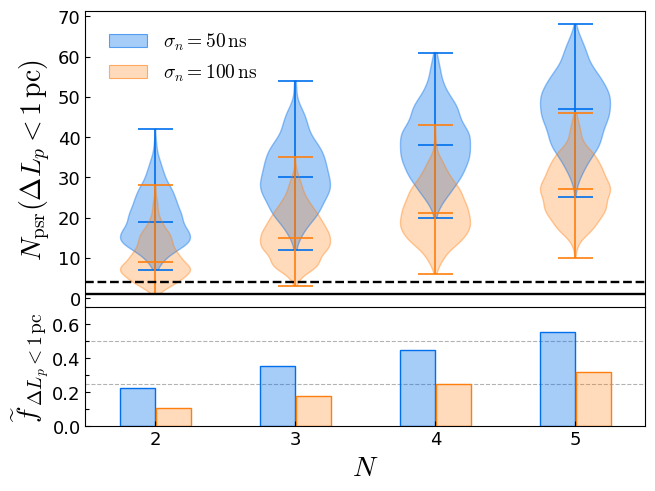

In [9]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch, PathPatch
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec

# ====== 全局设置 ======
mpl.rcParams.update({'patch.force_edgecolor': True, 'patch.antialiased': True})
plt.rcParams.update({'mathtext.fontset': 'cm', 'xtick.direction': 'in', 'ytick.direction': 'in', 'font.size': 20, 'axes.labelsize': 20, 'xtick.labelsize': 13, 'ytick.labelsize': 13})

# ====== 统一参数 ======
COLORS, ALPHAS, EDGE_ALPHA = ['#006fed', '#ff7f0e'], [0.35, 0.28], 0.4
POSITIONS, XTICKS, XTLABELS = [1, 2, 3, 4], [1, 2, 3, 4], [2, 3, 4, 5]
S_LIST, SIGMA_LIST = [2, 3, 4, 5], ["5e-08", "1e-07"]
TSPAN, DIST, DP_THRESH, BAD_FLAG, RESULT_DIR, N_PSR_TOTAL = 2, "1.0Gpc", 1.0, 100, "results", 85
PSR_INFO_PATH = "./data/pulsar/pulsar_ra_dec_dist_85.txt"
PRIOR_LINE_STYLES = {'5e-08': '--', '1e-07': '-'}

# ====== 计算仅靠视差先验达标的脉冲星数量 ======
def count_prior_only(sigma_str):
    psr_info = np.loadtxt(PSR_INFO_PATH)
    psr_prior_pc = psr_info[:, 3] * 1e6 * (float(sigma_str) / 2e-8) / 2**0.5
    n_prior = np.sum(psr_prior_pc < DP_THRESH)
    # print(f"  sigma={sigma_str}: 仅先验 < {DP_THRESH} pc 的脉冲星数 = {n_prior}")
    return n_prior

N_PRIOR = {sigma: count_prior_only(sigma) for sigma in SIGMA_LIST}

# ====== 数据加载 ======
def load_count_per_real(s, sigma):
    csv_path = Path(RESULT_DIR) / f"dp_all_pulsars_t{TSPAN}_{DIST}_{s}s_sigma_{sigma}.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"找不到文件: {csv_path}")
    df = pd.read_csv(csv_path)
    bad_reals = df.loc[df["dp"] == BAD_FLAG, "realization"].unique()
    df = df[~df["realization"].isin(bad_reals)].copy()
    all_zero_reals = df.groupby("realization")["dp"].apply(lambda x: (x == 0.0).all())
    all_zero_reals = all_zero_reals[all_zero_reals].index.tolist()
    df = df[~df["realization"].isin(all_zero_reals)].copy()
    all_reals = sorted(df["realization"].unique())
    count_per_real = df.loc[df["dp"] < DP_THRESH].groupby("realization")["pulsar_id"].nunique().reindex(all_reals, fill_value=0)
    zero_reals = count_per_real[count_per_real == 0]
    count_per_real = count_per_real[count_per_real > 0]
    return count_per_real

count_dict = {}
for sigma in SIGMA_LIST:
    # print(f"\n========== sigma = {sigma} ==========")
    count_dict[sigma] = {s: load_count_per_real(s, sigma) for s in S_LIST}

# ====== 小提琴绘制函数 ======
def draw_violin(ax, data_list, color, alpha, positions):
    vp = ax.violinplot(data_list, positions=positions, showmeans=False, showextrema=True, showmedians=True, widths=0.5, bw_method=0.25)
    for body in vp['bodies'][:]:
        path, z = body.get_paths()[0], body.get_zorder()
        ax.add_patch(PathPatch(path, facecolor=color, edgecolor='none', lw=0, alpha=alpha, zorder=z))
        ax.add_patch(PathPatch(path, facecolor='none', edgecolor=color, lw=1, alpha=EDGE_ALPHA, zorder=z + 1))
        body.remove()
    for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if part in vp:
            vp[part].set_edgecolor(color)
            vp[part].set_linewidth(1.2)

# ====== 创建图 ======
fig = plt.figure(figsize=(7, 5))
gs = GridSpec(2, 1, figure=fig, height_ratios=[5.5, 2.2], hspace=0, left=0.16, right=0.96, top=0.95, bottom=0.12)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1])

# ====== 上图：小提琴 ======
for sigma, color, alpha in zip(SIGMA_LIST, COLORS, ALPHAS):
    draw_violin(ax_top, [count_dict[sigma][s].values for s in S_LIST], color, alpha, POSITIONS)

for sigma in SIGMA_LIST:
    ax_top.axhline(N_PRIOR[sigma], color='k', lw=1.7, ls=PRIOR_LINE_STYLES[sigma], zorder=1000)

ax_top.set_xlim(0.5, 4.5)
ax_top.set_xticks(XTICKS)
ax_top.set_xticklabels([])
ax_top.tick_params(bottom=False)
ax_top.spines['bottom'].set_visible(False)
ax_top.set_ylabel(r"$N_{\rm psr}(\Delta L_p < 1\,\mathrm{pc})$", labelpad=0)
ax_top.legend(handles=[Patch(facecolor=to_rgba(c, a), edgecolor=to_rgba(c, 0.6), linewidth=0.8, label=lab) for c, a, lab in zip(COLORS, ALPHAS, [r'$\sigma_n = 50\,\mathrm{ns}$', r'$\sigma_n = 100\,\mathrm{ns}$'])], loc='upper left', bbox_to_anchor=(0.01, 0.99), fontsize=14, frameon=True, framealpha=0, columnspacing=1)

# ====== 下图：Fraction 柱状图 ======
bar_width, gap = 0.25, 0.0095
offsets = [-(bar_width + gap) / 2, (bar_width + gap) / 2]

for sigma, color, alpha, offset in zip(SIGMA_LIST, COLORS, ALPHAS, offsets):
    fracs = [np.median(count_dict[sigma][s].values) / N_PSR_TOTAL for s in S_LIST]
    xpos = [p + offset for p in POSITIONS]
    bars = ax_bot.bar(xpos, fracs, width=bar_width, color=color, linewidth=1.0)
    for bar in bars:
        bar.set_facecolor(to_rgba(color, alpha))
        bar.set_edgecolor(to_rgba(color, 1.0))

ax_bot.set_xlim(0.5, 4.5)
ax_bot.set_xticks(XTICKS)
ax_bot.set_xticklabels(XTLABELS)
ax_bot.set_xlabel(r"$N$", labelpad=3)
ax_bot.set_ylabel(r"$\widetilde{f}_{\,\Delta L_p < 1\,\mathrm{pc}}$", labelpad=0)
ax_bot.set_ylim(0, 0.7)
ax_bot.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax_bot.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
ax_bot.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax_bot.tick_params(axis='y', which='minor', length=3, width=0.8)
for yval in [0.25, 0.5, 1.0]:
    ax_bot.axhline(yval, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)

fig.align_ylabels([ax_top, ax_bot])
fig.savefig("./fig3.pdf", dpi=300, bbox_inches='tight')
plt.show()


# figS1

0.5345998052312154 6.148753329312175
323.17029436175784 991.3800560314465
Removed no burn in


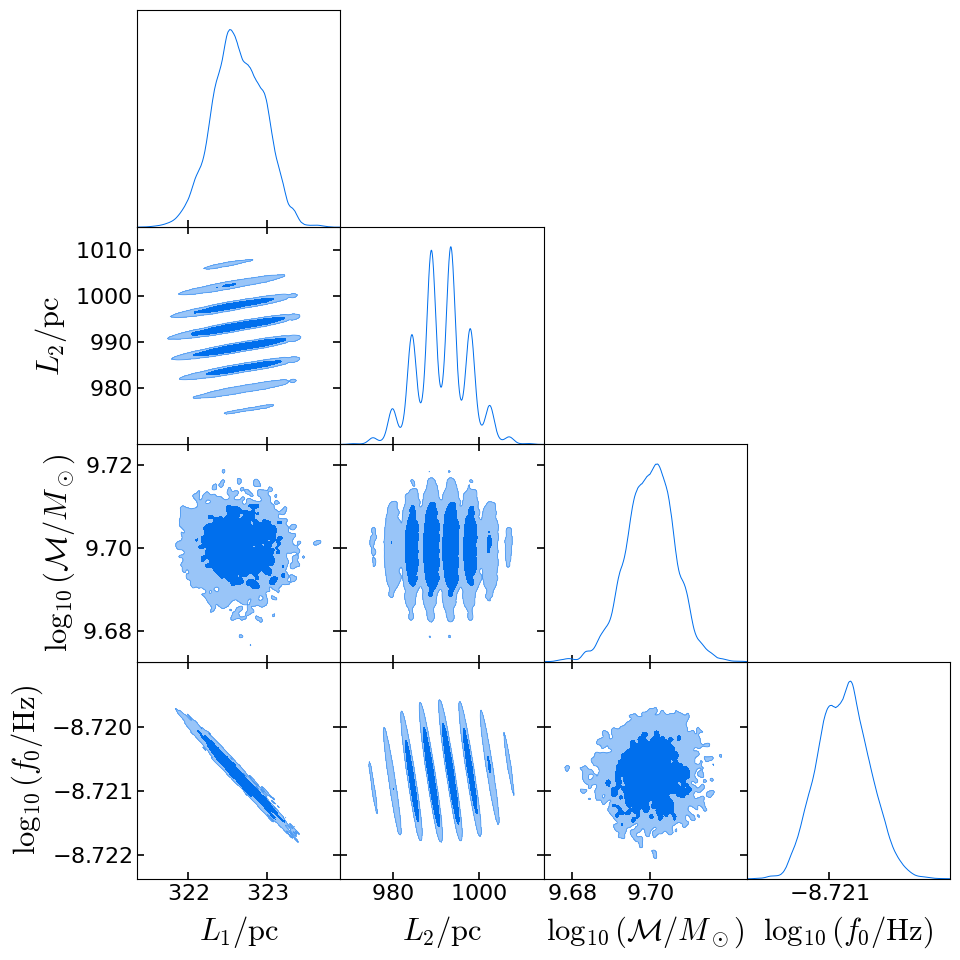

In [10]:
def plot_results(u, ss, pi_1, pi_2, tspan, nHz, Gpc, seed):
    pulsar_file = np.loadtxt('data/pulsar/pulsar_ra_dec_dist_85.txt')  # ← 改
    dp = pulsar_file[:, 2] * 1e6       # 距离，单位 pc
    dp_err = pulsar_file[:, 3] * 1e6   # ← col 4 → col 3

    dperr1 = dp_err[pi_1] / (tspan**0.5) * 5e-08 / 2e-08
    dperr2 = dp_err[pi_2] / (tspan**0.5) * 5e-08 / 2e-08


    # print(dperr1,dperr2)
    names = ["L_{1}/\mathrm{pc}", "L_{2}/\mathrm{pc}","\log_{10}({\mathcal{M}}/{M_\odot})","\log_{10}({f_0}/{\mathrm{Hz}})"]
    labels = ["L_{1}/\mathrm{pc}", "L_{2}/\mathrm{pc}","\log_{10}({\mathcal{M}}/{M_\odot})","\log_{10}({f_0}/{\mathrm{Hz}})"]
    smooth_scale = 0.08
    # ---------- 先验 ----------
    x_min = dp[pi_1] - 2 * dperr1
    x_max = dp[pi_1] + 2 * dperr1
    y_min = dp[pi_2] - 2 * dperr2
    y_max = dp[pi_2] + 2 * dperr2
    xg = np.linspace(x_min, x_max, 1024)
    yg = np.linspace(y_min, y_max, 1024)
    
    Yg, Xg = np.meshgrid(yg, xg, indexing='ij')
    np.random.seed(seed)
    loc_sample1 = np.random.normal(dp[pi_1], dperr1)
    np.random.seed(seed+5)
    loc_sample2 = np.random.normal(dp[pi_2], dperr2)
    # print(loc_sample1,loc_sample2)
    prior_x = stats_norm.pdf(xg, loc=loc_sample1, scale=dperr1)
    prior_y = stats_norm.pdf(yg, loc=loc_sample2, scale=dperr2)
    PRIOR = np.outer(prior_y, prior_x)
    PRIOR_safe = PRIOR + 1e-300
    # ---------- 每个源：读样本 + 加先验权重 ----------
    pdf_list = []
    per_source_titles = []
    mcs_list = []
    pdf_1d_list = []
    post1_1d = []
    post2_1d = []
    for s in ss:
        fname = f'dp_samples/s{s}_{pi_1}_{pi_2}_sigma_5e-08_Tspan_{tspan}.npy'
        data = np.load(fname)[:, [0, 1,2,3]]# *1e6
        data[:,0] = data[:,0]*1e6
        data[:,1] = data[:,1]*1e6
        mask = data[:,0] <= 324
        

        # ✨ 计算二维高斯先验的权重
        w_prior_1d = np.exp(-0.5 * (((data[mask, 0] - loc_sample1) / dperr1) ** 2 + ((data[mask, 1] - loc_sample2) / dperr2) ** 2)).astype(float)

        # 用带先验权重的 MCSamples
        ms = MCSamples(samples=data[mask], names=names, labels=labels,weights=w_prior_1d)
        # ms.updateSettings({'smooth_scale_2D': 0.04,'smooth_scale_1D': 3})
        ms.updateSettings({'smooth_scale_2D': 0.08,'smooth_scale_1D': 0.15})
        mcs_list.append(ms)

    g = plots.getSubplotPlotter()
    g.settings.fig_width_inch = 10

    g.settings.fontsize = 20           # 全局基准字体
    g.settings.axes_fontsize = 18      # 坐标轴刻度数字
    g.settings.axes_labelsize = 24     # 轴标签 / 参数标签
    g.settings.legend_fontsize = 20    # 图例
    g.settings.title_limit_fontsize = 20  # 顶部标题之类

    g.triangle_plot(mcs_list, params=["L_{1}/\mathrm{pc}", "L_{2}/\mathrm{pc}","\log_{10}({\mathcal{M}}/{M_\odot})","\log_{10}({f_0}/{\mathrm{Hz}})"], filled=True)#,legend_labels=['S1', 'S2', 'S3']
    for ax in g.fig.get_axes():
        ax.tick_params(axis='both', which='major', length=5, width=1.2)
        # ax.tick_params(axis='both', which='minor', length=3, width=1.0)

    plt.savefig('./figS1.pdf', bbox_inches='tight')
    plt.show()
    
plot_results(3, [78], 0, 1, 2, 10, 1.0, 72)

# figS2

68% HDI: [3.348, 9.072] nHz


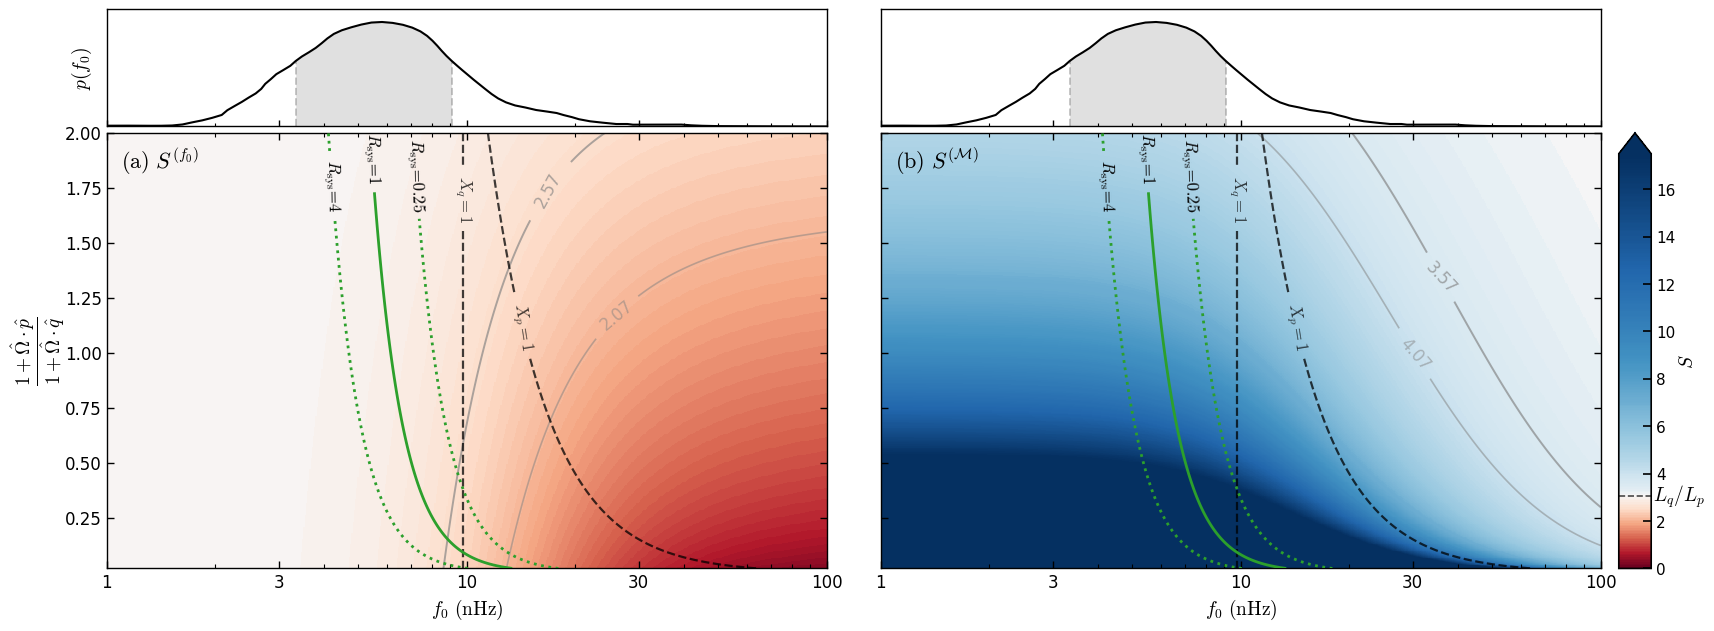

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.ticker import FixedLocator, FuncFormatter, LogLocator, NullFormatter

# ====== 物理常数 & 网格 ======
G_over_c3, M_chirp, kpc_in_s = 4.926e-6, 5e9 * 4.926e-6, 1.029e11
Lp, Lq = 0.323 * kpc_in_s, 0.990 * kpc_in_s
Lq_over_Lp, eps = Lq / Lp, 1e-30

def H_func(X):
    return 3.0 * X + 8.0 - 8.0 * (1.0 + X) ** (3.0 / 8.0)

def g_func(X):
    return 8.0 * ((1.0 + X) ** (3.0 / 8.0) - 1.0) / (H_func(X) + eps)

f0_vals = np.logspace(np.log10(1e-9), np.log10(1e-7), 600)
rho_vals = np.linspace(0.02, 2.0, 500)
F0, RHO = np.meshgrid(f0_vals, rho_vals)

Xp = (256 / 5) * M_chirp ** (5 / 3) * (np.pi * F0) ** (8 / 3) * Lp * RHO
Xq = (256 / 5) * M_chirp ** (5 / 3) * (np.pi * F0) ** (8 / 3) * Lq * 1.0

S = np.clip(RHO * (1 + Xp) ** (-3 / 8) * ((1 + Xq) ** (-3 / 8) - 1) / ((1 + Xq) ** (-3 / 8) * ((1 + Xp) ** (-3 / 8) - 1)), 0.0, 17.5)
S_M = np.clip(RHO * H_func(Xq) / (H_func(Xp) + eps), 0.0, 17.5)

# ====== 自定义 cmap ======
vcen_shared, vmin_shared, vmax_shared = Lq_over_Lp, 0.0, 17.5
mid_frac = (vcen_shared - vmin_shared) / (vmax_shared - vmin_shared)
cmap_base, n_half, blue_gamma = plt.cm.RdBu_r, 128, 0.55

positions_low = np.linspace(0.0, mid_frac, n_half)
colors_low = [cmap_base(x) for x in np.linspace(1.0, 0.5, n_half)]
t = np.linspace(0, 1, n_half)
colors_high = [cmap_base(x) for x in 0.5 * (1.0 - t ** blue_gamma)]
positions_high = np.linspace(mid_frac, 1.0, n_half)

positions_all = np.concatenate([positions_low, positions_high[1:]])
colors_all = colors_low + colors_high[1:]
cmap_custom = LinearSegmentedColormap.from_list('asym_RdBu_r', list(zip(positions_all, colors_all)), N=256)
norm_shared = Normalize(vmin=vmin_shared, vmax=vmax_shared)

# ====== PDF / HDI (f0) ======
x_raw = np.array([2.08559880457329e-9,2.16293134801984e-9,2.26531293656399e-9,2.37254072130499e-9,2.47751957194723e-9,2.59224003513388e-9,2.68571440822354e-9,2.75531299294631e-9,2.85747806959895e-9,2.95760499438095e-9,3.09455560365983e-9,3.23466314141216e-9,3.34800674901533e-9,3.48241353313500e-9,3.64366517290094e-9,3.80488802507012e-9,3.95374401044571e-9,4.10034607014860e-9,4.27335754210932e-9,4.49771003216381e-9,4.77595063338879e-9,5.09140455585085e-9,5.43303790537777e-9,5.81473483259069e-9,6.22324779657367e-9,6.64736571258839e-9,7.05858987315151e-9,7.43648183391325e-9,7.75788950601976e-9,8.02972837936074e-9,8.27844405008081e-9,8.51808325161001e-9,8.78192540032068e-9,9.07177578268415e-9,9.38965364186909e-9,9.72823802287045e-9,1.00889542775559e-8,1.04630456384104e-8,1.08616908083982e-8,1.12755244786608e-8,1.17166489732159e-8,1.22230471538981e-8,1.28521077803233e-8,1.36203426760500e-8,1.45485768618000e-8,1.55860133084540e-8,1.66974277387328e-8,1.77653042468136e-8,1.96216282225748e-9,1.84240292899501e-9,1.72655130145754e-9,1.62276790719602e-9,1.51923141278107e-9,1.41671356173230e-9,1.31981427247396e-9,1.22954262659562e-9,1.14544531162091e-9,1.06710002039306e-9,9.94113330396808e-10,9.26118728128794e-10,8.62774768595587e-10,8.03763360696934e-10,1.85879189114656e-8,1.96023298264628e-8,2.04898350187904e-8,2.19941758126050e-8,2.38189754570292e-8,2.48973913688715e-8,2.60246330952838e-8,2.72029112492053e-8,2.79353325798522e-8,2.89426612471675e-8,2.97219242557814e-8,3.07936761765806e-8,3.13439586816571e-8,3.30545134757324e-8,3.48584195191906e-8,3.64366517290094e-8,3.80863391838585e-8,3.94597060905645e-8,4.20e-8,4.50e-8,5.00e-8,7.00e-8,1.00e-7])
y_raw = np.array([1.00771315405462e-1,1.42873149885345e-1,1.79580988117573e-1,2.15611319574734e-1,2.52988847196164e-1,2.89694079633104e-1,3.29760787992495e-1,3.73866479049406e-1,4.15968313529289e-1,4.58742443193663e-1,4.95447675630602e-1,5.32150302272253e-1,5.74246925161559e-1,6.13646549927038e-1,6.51029289139045e-1,6.89084323535543e-1,7.30513862830936e-1,7.72615697310819e-1,8.12020533666875e-1,8.43998853450073e-1,8.69903064415260e-1,8.93785178236398e-1,9.11572336877215e-1,9.16494684177611e-1,9.08544402751720e-1,8.91781321659370e-1,8.66872524494476e-1,8.33812799666458e-1,7.94629455909944e-1,7.52037731915781e-1,7.08080571190327e-1,6.63440692099229e-1,6.18806024598707e-1,5.76209089013967e-1,5.34294871794872e-1,4.92383260371065e-1,4.50474254742547e-1,4.08565249114030e-1,3.67336356055868e-1,3.26107462997707e-1,2.84881175734834e-1,2.45697831978320e-1,2.11277882009589e-1,1.84331352928914e-1,1.66213258286429e-1,1.44200542005420e-1,1.30832812174276e-1,1.17961746925162e-1,7.55420054200542e-2,5.36950177194080e-2,3.59078590785908e-2,1.74510110485720e-2,8.46883468834688e-3,6.25130289764436e-3,6.06368563685637e-3,6.55357515113613e-3,7.04346466541588e-3,6.85584740462789e-3,6.66823014383990e-3,6.48061288305191e-3,5.61548884719616e-3,4.07285803627267e-3,9.97889305816135e-2,8.16369606003752e-2,6.34615384615385e-2,4.53564727954972e-2,3.33724202626642e-2,2.73921200750469e-2,2.14118198874296e-2,2.15290806754221e-2,2.15994371482176e-2,1.55956848030019e-2,1.56660412757974e-2,1.57598499061914e-2,1.58067542213884e-2,1.59474671669794e-2,1.60881801125704e-2,1.62054409005629e-2,1.63227016885553e-2,1.64165103189493e-2,1.00e-2,6.00e-3,3.00e-3,1.00e-3,0.0,0.0])

x_nHz = x_raw * 1e9
sort_idx = np.argsort(x_nHz)
freq_pdf = x_nHz[sort_idx]
y = np.clip(y_raw[sort_idx], 0, None)
u_ = np.log10(freq_pdf)
p_u = y / np.trapz(y, u_)
du = np.diff(u_, prepend=u_[0])
sorted_idx = np.argsort(p_u)[::-1]
cumsum, hdi_mask = 0.0, np.zeros(len(p_u), dtype=bool)
for i in sorted_idx:
    if cumsum >= 0.68:
        break
    hdi_mask[i] = True
    cumsum += p_u[i] * du[i]
hdi_lo, hdi_hi = freq_pdf[hdi_mask].min(), freq_pdf[hdi_mask].max()
pdf_vis = p_u / p_u.max()
# print(f"68% HDI: [{hdi_lo:.3f}, {hdi_hi:.3f}] nHz")

# ====== R_sys ======
eta_fixed = 0.05
R_sys = (eta_fixed * g_func(Xp)) * (eta_fixed * g_func(Xq))
Xq_1d = (256 / 5) * M_chirp ** (5 / 3) * (np.pi * f0_vals) ** (8 / 3) * Lq
f0_Xq1_nHz = f0_vals[np.argmin(np.abs(Xq_1d - 1.0))] * 1e9
R_sys_specs = [(0.25, ':', '#2ca02c', r'$R_{\rm sys}\!=\!0.25$'), (1.0, '-', '#2ca02c', r'$R_{\rm sys}\!=\!1$'), (4.0, ':', '#2ca02c', r'$R_{\rm sys}\!=\!4$')]
target = Lq_over_Lp

# ====== 辅助函数：PDF panel ======
def draw_pdf(ax, show_ylabel=True):
    if show_ylabel:
        ax.set_ylabel(r'$p(f_0)$', fontsize=14, labelpad=4)
    ax.fill_between(freq_pdf, 0, pdf_vis, where=hdi_mask, color='0.7', alpha=0.4, lw=0, zorder=0)
    ax.plot(freq_pdf, pdf_vis, color='k', lw=1.5, zorder=2)
    for fx in [hdi_lo, hdi_hi]:
        ax.plot([fx, fx], [0, np.interp(fx, freq_pdf, pdf_vis)], color='gray', ls='--', lw=1.4, alpha=0.45, zorder=1)
    ax.set_xscale('log')
    ax.set_xlim(1, 100)
    ax.set_ylim(0, 1.12)
    ax.set_yticks([])
    ax.xaxis.set_major_locator(FixedLocator([1, 3, 10, 30, 100]))
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='major', length=4, width=1.0, direction='in', bottom=True, top=False)
    ax.tick_params(axis='x', which='minor', length=2.5, width=0.8, direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', length=0)
    for sp in ax.spines.values():
        sp.set_linewidth(1.0)
    ax.patch.set_alpha(0)

# ====== 辅助函数：公共叠加层 ======
def draw_overlays(ax, S_data, contour_manual):
    m_outer, m_inner = contour_manual
    for delta, lw, alpha, manual in [(1.0, 1.2, 0.50, m_outer), (0.5, 1.4, 0.65, m_inner)]:
        cs = ax.contour(f0_vals * 1e9, rho_vals, S_data, levels=[target - delta, target + delta], colors='gray', linewidths=lw, alpha=alpha, zorder=1)
        for lbl in ax.clabel(cs, fmt='%.2f', fontsize=12, colors='gray', inline=True, inline_spacing=15, use_clabeltext=True, manual=manual):
            lbl.set_alpha(alpha)
    cs_Xq1 = ax.contour(f0_vals * 1e9, rho_vals, Xq, levels=[1.0], colors='k', linewidths=1.6, linestyles='--', alpha=0.75, zorder=3)
    for l in ax.clabel(cs_Xq1, fmt={1.0: r'$X_q=1$'}, fontsize=12, inline=True, inline_spacing=8, manual=[(f0_Xq1_nHz, 1.7)]):
        l.set_rotation(-90)
        l.set_fontweight('bold')
    cs_Xp1 = ax.contour(f0_vals * 1e9, rho_vals, Xp, levels=[1.0], colors='k', linewidths=1.6, linestyles='--', alpha=0.75, zorder=3)
    for l in ax.clabel(cs_Xp1, fmt={1.0: r'$X_p=1$'}, fontsize=12, inline=True, inline_spacing=8, manual=[(30, 1.2)]):
        l.set_fontweight('bold')
    for R_target, ls, col, label in R_sys_specs:
        cs_sys = ax.contour(f0_vals * 1e9, rho_vals, R_sys, levels=[R_target], colors=[col], linewidths=2.0, linestyles=[ls], alpha=1.0, zorder=5)
        for l in ax.clabel(cs_sys, fmt=label, fontsize=11, colors='k', inline=True, inline_spacing=10):
            l.set_alpha(1.0)
            l.set_fontweight('bold')
            l.set_fontsize(12)

# ====== 辅助函数：轴格式 ======
def format_main_ax(ax, show_ylabel=True):
    ax.set_xscale('log')
    ax.set_xlim(1, 100)
    ax.set_ylim(0.02, 2.0)
    ax.set_xlabel(r'$f_0\ \mathrm{(nHz)}$', fontsize=14)
    if show_ylabel:
        ax.set_ylabel(r'$\dfrac{1+\hat{\Omega}\cdot\hat{p}}{1+\hat{\Omega}\cdot\hat{q}}$', fontsize=14, labelpad=15)
    else:
        ax.set_yticklabels([])
    ax.xaxis.set_major_locator(FixedLocator([1, 3, 10, 30, 100]))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_major_locator(FixedLocator([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]))
    ax.tick_params(axis='both', which='major', labelsize=12, length=5, width=1.0, direction='in', top=True, right=True)
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in', top=True, right=True)
    for sp in ax.spines.values():
        sp.set_linewidth(1.0)

# ====== 布局 ======
fig = plt.figure(figsize=(18, 6.5))
left_L, right_L, left_R, right_R = 0.055, 0.455, 0.485, 0.875
width_col = right_L - left_L
bottom_pdf, height_pdf = 0.78, 0.18
bottom_main, height_main = 0.10, 0.67

ax_pdf_L = fig.add_axes([left_L, bottom_pdf, width_col, height_pdf])
ax_main_L = fig.add_axes([left_L, bottom_main, width_col, height_main])
ax_pdf_R = fig.add_axes([left_R, bottom_pdf, width_col, height_pdf])
ax_main_R = fig.add_axes([left_R, bottom_main, width_col, height_main])
cbar_ax = fig.add_axes([right_R + 0.02, bottom_main, 0.018, height_main])

# ====== 通用绘制函数 ======
def draw_panel(ax_pdf, ax_main, S_data, contour_manual, panel_label, show_ylabel):
    draw_pdf(ax_pdf, show_ylabel=show_ylabel)
    im = ax_main.pcolormesh(f0_vals * 1e9, rho_vals, S_data, cmap=cmap_custom, norm=norm_shared, shading='auto', zorder=0, rasterized=True)
    ax_main.set_zorder(im.get_zorder() + 1)
    ax_main.patch.set_visible(False)
    draw_overlays(ax_main, S_data, contour_manual)
    format_main_ax(ax_main, show_ylabel=show_ylabel)
    ax_main.text(0.02, 0.97, panel_label, transform=ax_main.transAxes, fontsize=16, color='k', weight='bold', ha='left', va='top')
    return im

draw_panel(ax_pdf_L, ax_main_L, S, ([(8, 1.9)], [(8, 1.9)]), r'$({\rm a})\ S^{(f_0)}$', True)
im_R = draw_panel(ax_pdf_R, ax_main_R, S_M, ([(15, 0.55)], [(15, 0.70)]), r'$({\rm b})\ S^{(\mathcal{M})}$', False)

# ====== colorbar ======
cbar = fig.colorbar(im_R, cax=cbar_ax, extend='max')
cbar.set_label(r'$S$', fontsize=14, labelpad=2)
cbar.ax.tick_params(labelsize=11, length=6, width=1.2)
cbar.outline.set_linewidth(1.2)
cbar.ax.axhline(y=vcen_shared, color='k', lw=1.2, ls='--', alpha=0.7)
cbar.ax.text(1.05, vcen_shared, r'$L_q/L_p$', va='center', ha='left', fontsize=14, transform=cbar.ax.get_yaxis_transform(), color='k')

ax_pdf_L.yaxis.set_label_coords(-0.018, 0.5)
ax_pdf_R.yaxis.set_label_coords(-0.018, 0.5)
ax_main_L.yaxis.set_label_coords(-0.055, 0.5)

plt.savefig('figS2.pdf', dpi=150, bbox_inches='tight')
plt.show()


# figS3

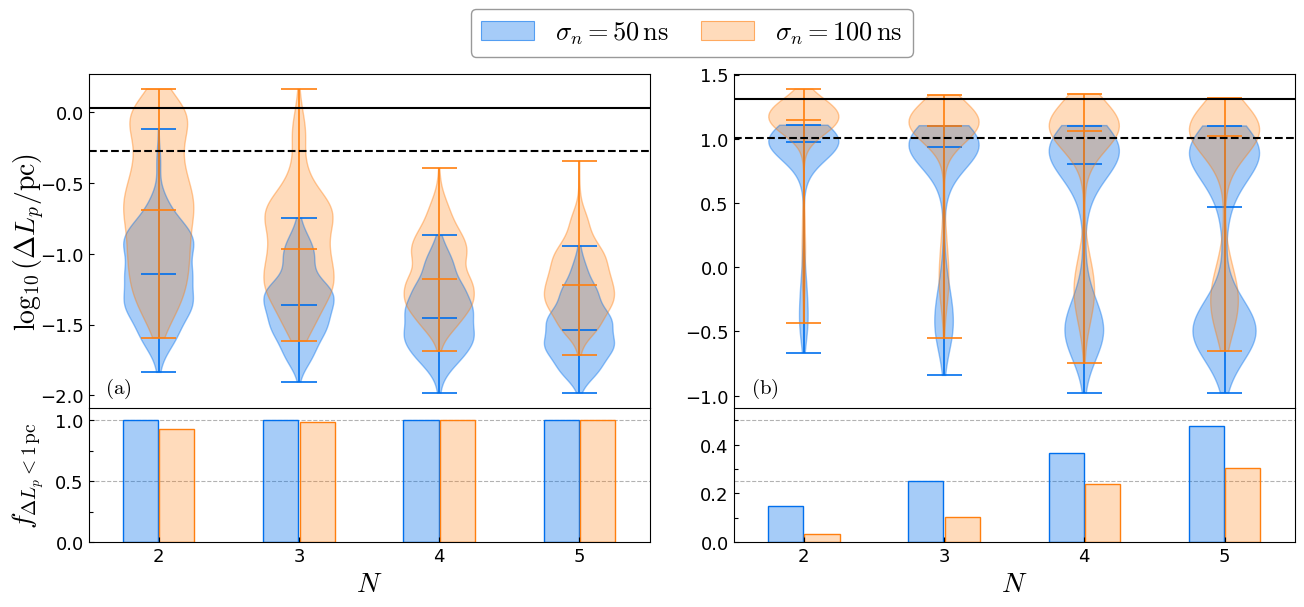

In [12]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, PathPatch
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec

# ====== 全局设置 ======
mpl.rcParams.update({'patch.force_edgecolor': True, 'patch.antialiased': True})
plt.rcParams.update({'font.size': 20, 'axes.labelsize': 20, 'xtick.labelsize': 13, 'ytick.labelsize': 13})

tspan = 2
COLORS, ALPHAS, EDGE_ALPHA = ['#006fed', '#ff7f0e'], [0.35, 0.28], 0.4
POSITIONS, XTICKS, XTLABELS = [1, 2, 3, 4], [1, 2, 3, 4], [2, 3, 4, 5]
THRESHOLD = 0.0

# ====== 数据加载 ======
dp = np.loadtxt('data/pulsar/pulsar_ra_dec_dist_85.txt')

def load_data(prefix, suffix, ns=(2, 3, 4, 5)):
    return [np.log10(np.loadtxt(f'results/{prefix}_t2_1.0Gpc_{n}s{suffix}.txt')) for n in ns]

data0     = load_data('dp0post', '')
data7     = load_data('dp7post', '')
data0_100 = load_data('dp0post', '_1e-07')
data7_100 = load_data('dp7post', '_1e-07')


def draw_panel(ax_top, ax_bot, data50, data100, yref, ylabel_top=False, ylabel_bot=False, panel_label=None):
    for data_list, color, alpha in zip((data50, data100), COLORS, ALPHAS):
        vp = ax_top.violinplot(data_list, showmeans=False, showextrema=True, showmedians=True, widths=0.5, positions=POSITIONS)
        for body in vp['bodies'][:]:
            path, z = body.get_paths()[0], body.get_zorder()
            ax_top.add_patch(PathPatch(path, facecolor=color, edgecolor='none', lw=0, alpha=alpha, zorder=z))
            ax_top.add_patch(PathPatch(path, facecolor='none', edgecolor=color, lw=1, alpha=EDGE_ALPHA, zorder=z + 1))
            body.remove()
        for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            if part in vp:
                vp[part].set_edgecolor(color)
                vp[part].set_linewidth(1.2)

    ax_top.axhline(np.log10(yref * 1e6), color='k', lw=1.5, ls='--')
    ax_top.axhline(np.log10(yref * 1e6 * 2), color='k', lw=1.5, ls='-')
    ax_top.set_xlim(0.5, 4.5)
    ax_top.set_xticks(XTICKS)
    ax_top.set_xticklabels([])
    ax_top.tick_params(bottom=False)
    ax_top.spines['bottom'].set_visible(False)
    if ylabel_top:
        ax_top.set_ylabel(r"$\log_{10}(\Delta L_{p}/\mathrm{pc})$", labelpad=-5)
    if panel_label is not None:
        ax_top.text(0.03, 0.025, panel_label, transform=ax_top.transAxes, ha='left', va='bottom', fontsize=15)

    bar_width, gap = 0.25, 0.0095
    offsets = [-(bar_width + gap) / 2, (bar_width + gap) / 2]
    for data_list, color, alpha, offset in zip([data50, data100], COLORS, ALPHAS, offsets):
        fracs = [np.mean(np.array(d) < THRESHOLD) for d in data_list]
        xpos = [p + offset for p in POSITIONS]
        bars = ax_bot.bar(xpos, fracs, width=bar_width, color=color, linewidth=1.0)
        for bar in bars:
            bar.set_facecolor(to_rgba(color, alpha))
            bar.set_edgecolor(to_rgba(color, 1.0))

    ax_bot.set_xlim(0.5, 4.5)
    ax_bot.set_xticks(XTICKS)
    ax_bot.set_xticklabels(XTLABELS)
    ax_bot.set_xlabel("$N$", labelpad=3)
    if ylabel_bot:
        ax_bot.set_ylabel(r"$f_{\Delta L_p < 1\,\mathrm{pc}}$", labelpad=-4)
    ax_bot.set_ylim(0, 1.10)
    ax_bot.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))
    ax_bot.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    ax_bot.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.25))
    ax_bot.tick_params(axis='y', which='minor', length=3, width=0.8)
    for yval in [0.5, 1.0]:
        ax_bot.axhline(yval, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)


# ====== 创建图 ======
fig = plt.figure(figsize=(13.4, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[5.5, 2.2], hspace=0, wspace=0.15, left=0.08, right=0.98, top=0.90, bottom=0.12)
ax00, ax10, ax01, ax11 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])

draw_panel(ax00, ax10, data0, data0_100, dp[0, 3] * 5e-08 / 2e-08 / (tspan ** 0.5), ylabel_top=True, ylabel_bot=True, panel_label=r"$\mathrm{(a)}$")
draw_panel(ax01, ax11, data7, data7_100, dp[7, 3] * 5e-08 / 2e-08 / (tspan ** 0.5), panel_label=r"$\mathrm{(b)}$")

ax11.set_ylim(0, 0.55)
ax11.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax11.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
ax11.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax11.axhline(0.25, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)

fig.legend(
    handles=[Patch(facecolor=to_rgba(c, a), edgecolor=to_rgba(c, 0.6), linewidth=0.8, label=lab) for c, a, lab in zip(COLORS, ALPHAS, [r'$\sigma_n = 50\,\mathrm{ns}$', r'$\sigma_n = 100\,\mathrm{ns}$'])],
    loc="upper center", ncol=2, frameon=True, framealpha=0.4, edgecolor='black', facecolor='white', fontsize=19, columnspacing=1.2, bbox_to_anchor=(0.53, 1.03)
)

fig.align_ylabels([ax00, ax10])
fig.savefig("./figS3.pdf", dpi=300, bbox_inches='tight')
plt.show()


# figS4

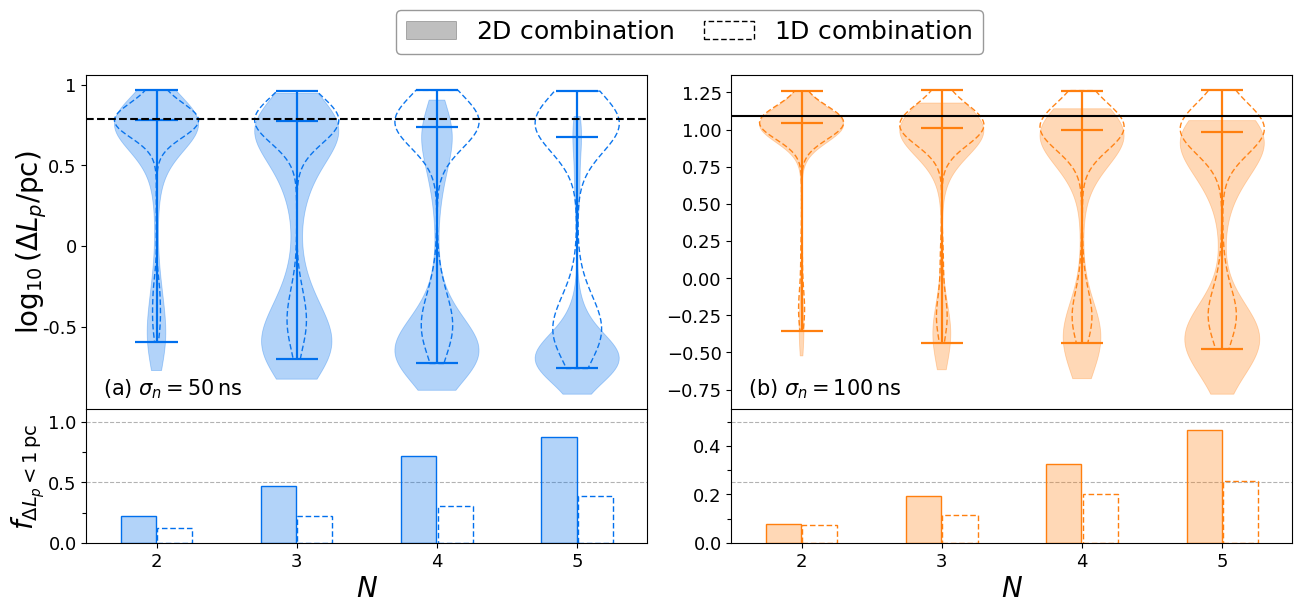

In [1]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, PathPatch
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec

# ====== 全局设置 ======
mpl.rcParams.update({'patch.force_edgecolor': True, 'patch.antialiased': True})
plt.rcParams.update({'font.size': 20, 'axes.labelsize': 20, 'xtick.labelsize': 13, 'ytick.labelsize': 13})

tspan = 2
POSITIONS, XTICKS, XTLABELS = [1, 2, 3, 4], [1, 2, 3, 4], [2, 3, 4, 5]
THRESHOLD = 0.0

# ====== 数据加载 ======
dp = np.loadtxt('data/pulsar/pulsar_ra_dec_dist_85.txt')

def load_data_2d(prefix, suffix, ns=(2, 3, 4, 5)):
    """加载 2D combination 后验样本（与 Fig2 相同的数据）"""
    return [np.log10(np.loadtxt(f'results/{prefix}_t2_1.0Gpc_{n}s{suffix}.txt')) for n in ns]

def load_data_1d(prefix, sigma_str, ns=(2, 3, 4, 5)):
    """加载 1D combination 后验样本"""
    return [np.log10(np.loadtxt(f'results/{prefix}_t2_1.0Gpc_{n}s_sigma{sigma_str}_1d.txt')) for n in ns]

# 2D combination 数据（原本依赖 Fig2 的 cell，现在显式加载）
data1     = load_data_2d('dp1post', '')
data1_100 = load_data_2d('dp1post', '_1e-07')

# 1D combination 数据
data1_50_1d  = load_data_1d('dp1post', '5e-08')
data1_100_1d = load_data_1d('dp1post', '1e-07')


def draw_panel(ax_top, ax_bot, data2d, data1d, yref, face_color='#006fed', lineshape='-.', ylabel_top=False, ylabel_bot=False, panel_label=None):
    # ====== 上图：violin ======
    vp2d = ax_top.violinplot(data2d, showmeans=False, showextrema=False, showmedians=False, widths=0.6, positions=POSITIONS)
    vp1d = ax_top.violinplot(data1d, showmeans=False, showextrema=True, showmedians=True, widths=0.6, positions=POSITIONS)

    for body in vp2d['bodies']:
        path, z = body.get_paths()[0], body.get_zorder()
        ax_top.add_patch(PathPatch(path, facecolor=face_color, edgecolor='none', alpha=0.30, zorder=z))
        ax_top.add_patch(PathPatch(path, facecolor='none', edgecolor=face_color, lw=0.6, alpha=0.3, zorder=z + 1))
        body.remove()
    for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if part in vp2d:
            vp2d[part].set_edgecolor(face_color)
            vp2d[part].set_linewidth(1.2)

    for body in vp1d['bodies']:
        path = body.get_paths()[0]
        ax_top.add_patch(PathPatch(path, facecolor='none', edgecolor=face_color, lw=1.0, alpha=0.95, linestyle=(0, (4, 2))))
        body.remove()
    for part in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        if part in vp1d:
            vp1d[part].set_edgecolor(face_color)
            vp1d[part].set_linewidth(1.6)

    ax_top.axhline(np.log10(yref * 1e6), color='k', lw=1.5, ls=lineshape)
    ax_top.set_xlim(0.5, 4.5)
    ax_top.set_xticks(XTICKS)
    ax_top.set_xticklabels([])
    ax_top.tick_params(bottom=False)
    ax_top.spines['bottom'].set_visible(False)
    if ylabel_top:
        ax_top.set_ylabel(r"$\log_{10}(\Delta L_{p}/\mathrm{pc})$", labelpad=-5)
    if panel_label is not None:
        ax_top.text(0.03, 0.025, panel_label, transform=ax_top.transAxes, ha='left', va='bottom', fontsize=15)

    # ====== 下图：fraction bar ======
    bar_width, gap = 0.25, 0.0095
    offsets = [-(bar_width + gap) / 2, (bar_width + gap) / 2]
    for data_list, offset, alpha_fill, ls_edge in zip([data2d, data1d], offsets, [0.30, 0], ['-', (0, (4, 2))]):
        fracs = [np.mean(np.array(d) < THRESHOLD) for d in data_list]
        xpos = [p + offset for p in POSITIONS]
        bars = ax_bot.bar(xpos, fracs, width=bar_width, color=face_color, linewidth=1.0)
        for bar in bars:
            bar.set_facecolor(to_rgba(face_color, alpha_fill))
            bar.set_edgecolor(to_rgba(face_color, 1.0))
            bar.set_linestyle(ls_edge)

    ax_bot.set_xlim(0.5, 4.5)
    ax_bot.set_xticks(XTICKS)
    ax_bot.set_xticklabels(XTLABELS)
    ax_bot.set_xlabel("$N$", labelpad=3)
    if ylabel_bot:
        ax_bot.set_ylabel(r"$f_{\Delta L_p < 1\,\mathrm{pc}}$", labelpad=-4)
    ax_bot.set_ylim(0, 1.10)
    ax_bot.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.5))
    ax_bot.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
    ax_bot.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.25))
    ax_bot.tick_params(axis='y', which='minor', length=3, width=0.8)
    for yval in [0.5, 1.0]:
        ax_bot.axhline(yval, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)


# ====== 创建图 ======
fig = plt.figure(figsize=(13.4, 6))
gs = GridSpec(2, 2, figure=fig, height_ratios=[5.5, 2.2], hspace=0, wspace=0.15, left=0.08, right=0.98, top=0.90, bottom=0.12)
ax00, ax10, ax01, ax11 = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])

draw_panel(ax00, ax10, data1, data1_50_1d, dp[1, 3] * 5e-08 / 2e-08 / (tspan ** 0.5), face_color='#006fed', lineshape='--', ylabel_top=True, ylabel_bot=True, panel_label=r"$\mathrm{(a)}$ $\sigma_n = 50\,\mathrm{ns}$")
draw_panel(ax01, ax11, data1_100, data1_100_1d[:][0:500], dp[1, 3] * 1e-07 / 2e-08 / (tspan ** 0.5), face_color='#ff7f0e', lineshape='-', panel_label=r"$\mathrm{(b)}$ $\sigma_n = 100\,\mathrm{ns}$")

ax00.set_yticks([-0.5, 0, 0.5, 1])
ax00.set_yticklabels(['-0.5', '0', '0.5', '1'])

ax11.set_ylim(0, 0.55)
ax11.yaxis.set_major_locator(mpl.ticker.MultipleLocator(0.2))
ax11.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.1f'))
ax11.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax11.axhline(0.25, color='gray', lw=0.8, ls='--', alpha=0.6, zorder=0)

fig.legend(
    handles=[Patch(facecolor=to_rgba('k', 0.25), edgecolor=to_rgba('k', 0.3), linewidth=0.6, label=r'$\mathrm{2D\ combination}$'),
             Patch(facecolor='none', edgecolor='k', linewidth=1.0, linestyle=(0, (4, 2)), label=r'$\mathrm{1D\ combination}$')],
    loc="upper center", ncol=2, frameon=True, framealpha=0.4, edgecolor='black', facecolor='white', fontsize=18, columnspacing=1.2, bbox_to_anchor=(0.53, 1.03)
)

fig.align_ylabels([ax00, ax10])
fig.savefig("./figS4.pdf", dpi=300, bbox_inches='tight')
plt.show()


# figS5

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
  s=13  data.shape=(100000, 2)
Removed no burn in
  s=45  data.shape=(100000, 2)
Removed no burn in
  s=78  data.shape=(100000, 2)
Removed no burn in
Removed no burn in
[2D joint y] q16=986.7848  q84=996.2831  half-sigma=4.7491
[Fig 1 L2] q16=989.3522  q84=990.2875  half-sigma=0.4676


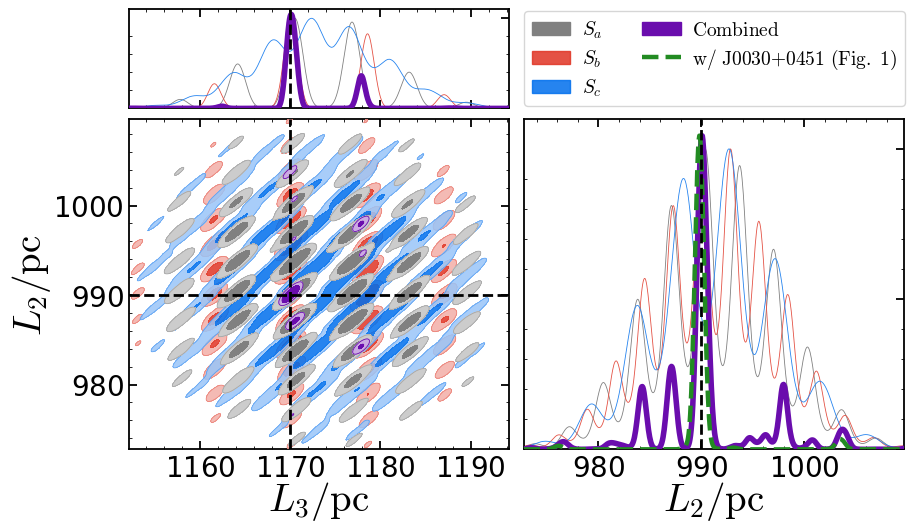

In [43]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mc
from matplotlib.gridspec import GridSpec
from matplotlib.font_manager import FontProperties
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import norm as stats_norm
from getdist import MCSamples, plots

# ====== 全局设置 ======
mpl.rcParams.update({'font.size': 20, 'axes.labelsize': 30, 'xtick.labelsize': 30, 'ytick.labelsize': 30, 'legend.fontsize': 30})
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'cm', 'xtick.direction': 'in', 'ytick.direction': 'in'})

# ====== 数据加载 ======
pulsar_file = np.loadtxt('data/pulsar/pulsar_ra_dec_dist_85.txt')
dp = pulsar_file[:, 2] * 1e6
dp_err = pulsar_file[:, 3] * 1e6   # col 4 → col 3

NAMES, LABELS = ["dp1", "dp2"], ["dp1", "dp2"]
SMOOTH_SETTINGS = {'smooth_scale_2D': 0.06, 'smooth_scale_1D': 0.12, 'fine_bins_2D': 1200}
JOINT_SMOOTH = {'smooth_scale_2D': 0.06, 'smooth_scale_1D': 0.06, 'fine_bins_2D': 1200}
NGRID, NSAMP = 2048, 1_000_000


# ====== 工具函数 ======
def sample_from_2d_grid(x, y, pdf, n_samples=30000, jitter=True, rng=None):
    dx, dy = x[1] - x[0], y[1] - y[0]
    rng = np.random.default_rng() if rng is None else rng
    pmass = (pdf * dx * dy).ravel()
    pmass[pmass < 1e-15] = 0.0
    pmass /= pmass.sum()
    idx = rng.choice(pmass.size, size=n_samples, p=pmass)
    iy, ix = np.divmod(idx, pdf.shape[1])
    jx, jy = (rng.random(n_samples), rng.random(n_samples)) if jitter else (0.5, 0.5)
    return np.column_stack([x[ix] + (jx - 0.5) * dx, y[iy] + (jy - 0.5) * dy])


def cdf_quantiles(x, p, tag=""):
    p = np.clip(p, 0, None)
    p = p / np.trapz(p, x)
    cdf = np.cumsum(p * np.gradient(x))
    cdf /= cdf[-1]
    q16, q84 = np.interp(0.16, cdf, x), np.interp(0.84, cdf, x)
    # print(f"[{tag}] q16={q16:.4f}  q84={q84:.4f}  half-sigma={0.5*(q84-q16):.4f}")
    return q16, q84


def update_legend(ax, new_handle, new_label, fontsize=14, **kw):
    handles, labels = [], []
    old = ax.get_legend()
    if old is not None:
        handles, labels = list(old.legend_handles), [t.get_text() for t in old.get_texts()]
        old.remove()
    handles.append(new_handle)
    labels.append(new_label)
    col1_h, col1_l, col2_h, col2_l = [], [], [], []
    for h, l in zip(handles, labels):
        (col2_h if any(k in l for k in ["+", "1D", "2D", "Fig"]) else col1_h).append(h)
        (col2_l if any(k in l for k in ["+", "1D", "2D", "Fig"]) else col1_l).append(l)
    ax.legend(handles=col1_h + col2_h, labels=col1_l + col2_l, loc="upper left", frameon=True,
              prop=FontProperties(size=fontsize), ncol=2, labelspacing=0.4, handletextpad=0.6, borderaxespad=0.0, **kw)


def dperr_scaled(pi, sigma=5e-8, tspan=2):
    return dp_err[pi] / (tspan ** 0.5) * sigma / 2e-8


def build_grid_and_prior(pi_x, pi_y, dperr_x, dperr_y, loc_x, loc_y):
    xg = np.linspace(dp[pi_x] - 5 * dperr_x, dp[pi_x] + 5 * dperr_x, NGRID)
    yg = np.linspace(dp[pi_y] - 5 * dperr_y, dp[pi_y] + 5 * dperr_y, NGRID)
    prior_x = stats_norm.pdf(xg, loc=loc_x, scale=dperr_x)
    prior_y = stats_norm.pdf(yg, loc=loc_y, scale=dperr_y)
    return xg, yg, np.outer(prior_y, prior_x) + 1e-300


def interpolate_2d_on_grid(ms, xg, yg):
    d_i = ms.get2DDensity("dp1", "dp2", resolution=NGRID, ranges={"dp1": [xg[0], xg[-1]], "dp2": [yg[0], yg[-1]]})
    f_interp = RegularGridInterpolator((d_i.y, d_i.x), d_i.P, bounds_error=False, fill_value=0.0)
    Yg, Xg = np.meshgrid(yg, xg, indexing='ij')
    return f_interp(np.column_stack([Yg.ravel(), Xg.ravel()])).reshape(len(yg), len(xg))


def compute_joint(pdf_list, PRIOR_safe, xg, yg):
    pdf_joint = np.ones_like(PRIOR_safe)
    for P in pdf_list:
        pdf_joint *= P
    if len(pdf_list) > 1:
        pdf_joint /= PRIOR_safe ** (len(pdf_list) - 1)
    dx, dy = float(np.mean(np.diff(xg))), float(np.mean(np.diff(yg)))
    Z = pdf_joint.sum() * dx * dy
    if Z > 0:
        pdf_joint /= Z
    joint_samples = sample_from_2d_grid(xg, yg, pdf_joint, n_samples=NSAMP, jitter=True)
    joint_MS = MCSamples(samples=joint_samples, names=NAMES, labels=LABELS)
    joint_MS.updateSettings(JOINT_SMOOTH)
    return joint_MS, pdf_joint


def load_and_weight(fname, col_x, col_y, loc_x, loc_y, dperr_x, dperr_y):
    raw = np.load(fname)[:, [0, 1]] * 1e6
    data = raw[:, [col_x, col_y]]
    w = np.exp(-0.5 * (((data[:, 0] - loc_x) / dperr_x) ** 2 + ((data[:, 1] - loc_y) / dperr_y) ** 2)).astype(float)
    return data, w


# ====== 绘图函数 ======
def plot_2p_custom(samples, filled=True, legend_labels=None, fig_width=10, top_height=0.45, hgap=0.05, wgap=0.05, legend_in_blank=True):
    g = plots.getSubplotPlotter()
    g.settings.fig_width_inch = fig_width
    g.make_figure(nx=7, ny=4)
    fig = g.fig
    fig.clf()
    gs = GridSpec(2, 2, figure=fig, height_ratios=[top_height, 1.0], hspace=hgap, wspace=wgap)
    ax_x, ax_blank = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
    ax_2d, ax_y = fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])
    ax_blank.set_xticks([])
    ax_blank.set_yticks([])
    for sp in ax_blank.spines.values():
        sp.set_visible(False)
    g.subplots = [[ax_x, ax_blank], [ax_2d, ax_y]]
    g.plot_1d(samples, "dp1", ax=ax_x, label_right=False, no_ylabel=True, no_ytick=True)
    g.plot_2d(samples, "dp1", "dp2", filled=filled, ax=ax_2d)
    g.plot_1d(samples, "dp2", ax=ax_y, label_right=False)
    ax_x.tick_params(axis='x', which='both', labelbottom=False)
    ax_x.tick_params(axis='y', which='both', labelleft=False)
    ax_x.set_xlabel("")
    ax_x.set_ylabel("")
    ax_x.set_title("")
    for t in list(ax_x.texts):
        t.remove()
    colors = ['#808080', '#e45245', '#2684ef']
    n = len(samples)
    for ax_1d in (ax_x, ax_y):
        for i, ln in enumerate(ax_1d.lines[-n:]):
            ln.set_color(colors[i % len(colors)])

    def _reorder_zorder(ax, n_groups=3, order=(1, 2, 0), z_base=10, z_step=10):
        for container, is_line in [(list(ax.collections), False), (list(ax.lines), True)]:
            if len(container) < n_groups:
                continue
            k = len(container) // n_groups
            groups = [container[i * k:(i + 1) * k] for i in range(n_groups - 1)]
            groups.append(container[(n_groups - 1) * k:])
            for rank, gi in enumerate(order):
                z = z_base + rank * z_step + (1 if is_line else 0)
                for a in groups[gi]:
                    a.set_zorder(z)
        ax.figure.canvas.draw_idle()

    _reorder_zorder(ax_2d, n_groups=3, order=(1, 2, 0))
    for ax in (ax_x, ax_2d, ax_y):
        for sp in ax.spines.values():
            sp.set_linewidth(1.3)
        ax.tick_params(width=1.3, length=6)
    g.settings.legend_fontsize = 16
    if legend_labels is not None:
        g.add_legend(ax=ax_blank if legend_in_blank else ax_2d, legend_labels=legend_labels, frameon=False, legend_loc="upper left")
    return fig, ax_x, ax_y, ax_2d, ax_blank


def draw_joint_ms_on_axes(joint_MS, ax_x, ax_y, ax_2d, color="#6A0DAD", lw=4, legend_label=None, legend_fontsize=14, legend_ax=None):
    def _lighten(c, amount=0.5):
        return tuple(np.array(mc.to_rgb(c)) + (1.0 - np.array(mc.to_rgb(c))) * amount)

    d2 = joint_MS.get2DDensity("dp1", "dp2")
    X, Y = np.meshgrid(d2.x, d2.y)
    try:
        lev = np.array(d2.getContourLevels())
    except Exception:
        lev = np.linspace(d2.P.max() * 0.2, d2.P.max() * 0.9, 2)
    l1, l2 = lev.max() + 0.07, lev.min() + 0.02
    ax_2d.contourf(X, Y, d2.P, levels=[l2, l1, d2.P.max()], colors=[_lighten(color, 0.65), color], zorder=120)
    ax_2d.contour(X, Y, d2.P, levels=[l2, l1], colors=color, linewidths=0.6, zorder=121)

    for par, ax in [("dp1", ax_x), ("dp2", ax_y)]:
        d1 = joint_MS.get1DDensity(par)
        P_norm = d1.P / np.max(d1.P) if np.max(d1.P) > 0 else d1.P
        ax.plot(d1.x, P_norm * 0.95 * ax.get_ylim()[1], color=color, lw=lw, zorder=80)

    d1y = joint_MS.get1DDensity("dp2")
    Py = d1y.P / np.max(d1y.P) if np.max(d1y.P) > 0 else d1y.P
    cdf_quantiles(np.asarray(d1y.x), Py, tag="2D joint y")

    if legend_label is not None:
        patch = mpatches.Patch(facecolor=color, edgecolor=color, label=legend_label, alpha=1)
        update_legend(legend_ax or ax_2d, patch, legend_label, fontsize=legend_fontsize)


def overlay_fig1_L2_on_ax_y(fig1_joint_MS, ax_y, legend_ax=None, color='C2', ls='--', lw=3, legend_label=r'$L_2\ \mathrm{(Fig.\ 1)}$', legend_fontsize=14):
    d1y = fig1_joint_MS.get1DDensity("dp2")
    Py = d1y.P / np.max(d1y.P) if np.max(d1y.P) > 0 else d1y.P
    ymax = ax_y.get_ylim()[1]
    line, = ax_y.plot(d1y.x, Py * 0.95 * ymax, ls=ls, lw=lw, color=color, zorder=85, label=legend_label)
    cdf_quantiles(np.asarray(d1y.x), np.clip(d1y.P, 0, None), tag="Fig 1 L2")
    update_legend(legend_ax or ax_y, line, legend_label, fontsize=legend_fontsize, bbox_to_anchor=(0.0, 0.98))
    return line


# ====== 主计算函数 ======
def compute_fig1_joint_MS(ss, pi_1, pi_2, tspan, Gpc, seed):
    dperr1, dperr2 = dperr_scaled(pi_1, tspan=tspan), dperr_scaled(pi_2, tspan=tspan)
    np.random.seed(seed)
    loc1 = np.random.normal(dp[pi_1], dperr1)
    np.random.seed(seed + 5)
    loc2 = np.random.normal(dp[pi_2], dperr2)
    xg, yg, PRIOR_safe = build_grid_and_prior(pi_1, pi_2, dperr1, dperr2, loc1, loc2)

    pdf_list = []
    for s in ss:
        data, w = load_and_weight(f'dp_samples/samples_s{s}_{pi_1}_{pi_2}_sigma_5e-08_Tspan_{tspan}.npy',
                                  0, 1, loc1, loc2, dperr1, dperr2)
        ms = MCSamples(samples=data, names=NAMES, labels=LABELS, weights=w, label=f's{s}')
        ms.updateSettings(SMOOTH_SETTINGS)
        pdf_list.append(interpolate_2d_on_grid(ms, xg, yg))

    joint_MS, _ = compute_joint(pdf_list, PRIOR_safe, xg, yg)
    return joint_MS


def plot_results_seed(ss, pi_1, pi_2, tspan, seed, seed2, seed3, swap_axes=False, fig1_joint_MS=None):
    dperr1, dperr2 = dperr_scaled(pi_1, tspan=tspan), dperr_scaled(pi_2, tspan=tspan)
    np.random.seed(seed + 5)
    loc_1 = np.random.normal(dp[pi_1], dperr1)
    np.random.seed(seed + pi_2 + seed3)
    loc_2 = np.random.normal(dp[pi_2], dperr2)

    if swap_axes:
        pi_x, pi_y, dperr_x, dperr_y, loc_x, loc_y, col_x, col_y = pi_2, pi_1, dperr2, dperr1, loc_2, loc_1, 1, 0
    else:
        pi_x, pi_y, dperr_x, dperr_y, loc_x, loc_y, col_x, col_y = pi_1, pi_2, dperr1, dperr2, loc_1, loc_2, 0, 1

    xg, yg, PRIOR_safe = build_grid_and_prior(pi_x, pi_y, dperr_x, dperr_y, loc_x, loc_y)

    pdf_list, mcs_list = [], []
    for s in ss:
        data, w = load_and_weight(f'dp_samples/samples_s{s}_{pi_1}_{pi_2}_sigma_5e-08_Tspan_{tspan}.npy',
                                  col_x, col_y, loc_x, loc_y, dperr_x, dperr_y)
        # print(f"  s={s}  data.shape={data.shape}")
        ms = MCSamples(samples=data, names=NAMES, labels=LABELS, weights=w, label=f's{s}')
        ms.updateSettings(SMOOTH_SETTINGS)
        mcs_list.append(ms)
        pdf_list.append(interpolate_2d_on_grid(ms, xg, yg))

    joint_MS, _ = compute_joint(pdf_list, PRIOR_safe, xg, yg)

    fig, ax_x, ax_y, ax_2d, ax_blank = plot_2p_custom(mcs_list, filled=True, legend_labels=[r'${S}_a$', r'${S}_b$', r'${S}_c$'],
                                                        fig_width=10, top_height=0.3, hgap=0.05, wgap=0.04)
    for ax in (ax_x, ax_y, ax_2d):
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.tick_params(axis='both', which='minor', labelsize=18)
    ax_x.axvline(dp[pi_x], ls='--', lw=2, color='k', zorder=140)
    ax_y.axvline(dp[pi_y], ls='--', lw=2, color='k', zorder=140)
    ax_2d.axvline(dp[pi_x], ls='--', lw=2, color='k', zorder=140)
    ax_2d.axhline(dp[pi_y], ls='--', lw=2, color='k', zorder=140)
    ax_x.set_xlim(loc_x - 3 * dperr_x, loc_x + 3 * dperr_x)
    ax_y.set_xlim(loc_y - 3 * dperr_y, loc_y + 3 * dperr_y)
    ax_2d.set_xlim(loc_x - 3 * dperr_x, loc_x + 3 * dperr_x)
    ax_2d.set_ylim(loc_y - 3 * dperr_y, loc_y + 3 * dperr_y)
    ax_2d.set_xlabel(rf"$L_{{{pi_x+1}}}/\mathrm{{pc}}$", fontsize=28, labelpad=20)
    ax_2d.set_ylabel(rf"$L_{{{pi_y+1}}}/\mathrm{{pc}}$", fontsize=28, labelpad=0)
    ax_y.set_xlabel(rf"$L_{{{pi_y+1}}}/\mathrm{{pc}}$", fontsize=28, labelpad=20)

    draw_joint_ms_on_axes(joint_MS, ax_x, ax_y, ax_2d, legend_label=r'$\mathrm{Combined}$', legend_fontsize=14, legend_ax=ax_blank)

    if fig1_joint_MS is not None:
        overlay_fig1_L2_on_ax_y(fig1_joint_MS, ax_y, legend_ax=ax_blank, color='forestgreen', ls='--', lw=3.2,
                                legend_label=r'$\mathrm{w/\ J0030{+}0451\ (Fig.\ 1)}$', legend_fontsize=14)

    fig.savefig('./figS5.pdf', bbox_inches='tight', pad_inches=0.03, dpi=300)
    plt.show()
    return joint_MS


# ====== 执行 ======
%matplotlib inline
fig1_joint_MS = compute_fig1_joint_MS(ss=[13, 45, 78], pi_1=0, pi_2=1, tspan=2, Gpc=1.0, seed=72)
plot_results_seed([13, 45, 78], 1, 2, tspan=2, seed=21, seed2=0, seed3=5, swap_axes=True, fig1_joint_MS=fig1_joint_MS)


# figS6

  已排除 pulsar_id: [40]
  已排除 pulsar_id: [40]
✅ 已保存：figS6.pdf


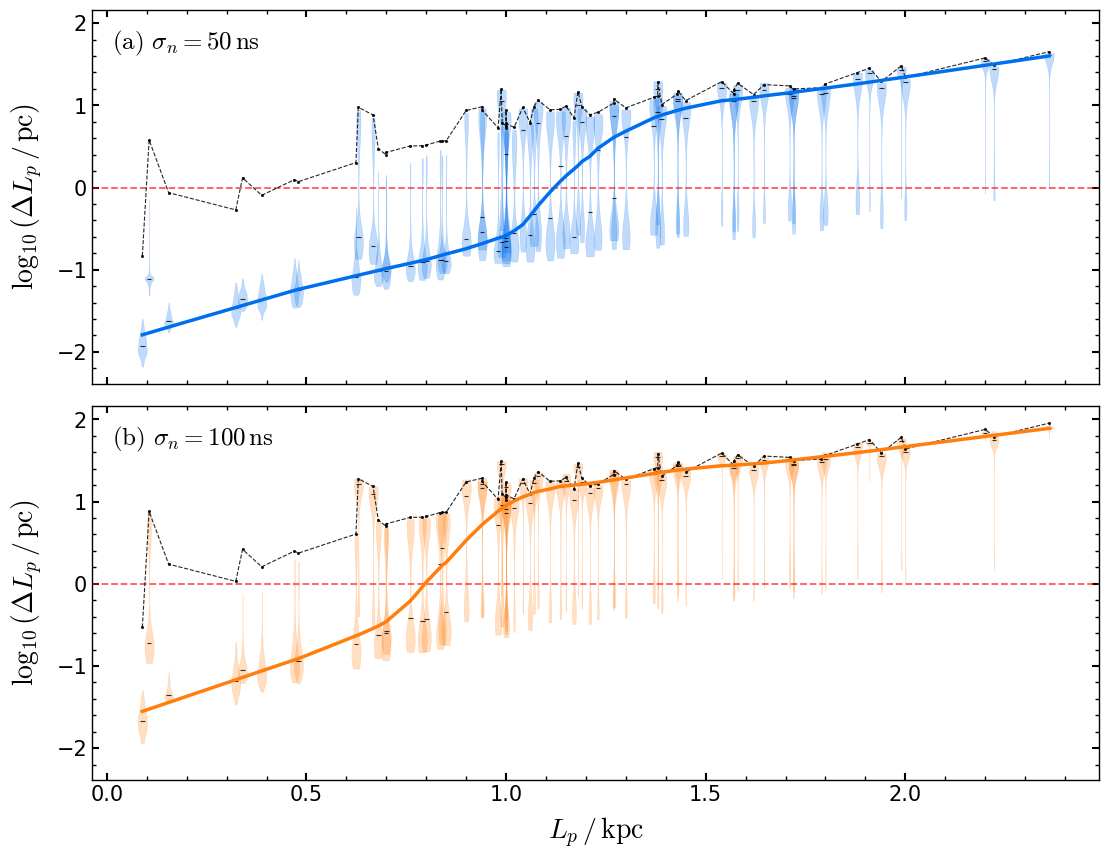

In [28]:
from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path


def _load_and_process(
    n, sigma_str, tspan=2, dist="1.0Gpc", result_dir="results",
    psr_info_path="./data/pulsar/pulsar_ra_dec_dist_85.txt",
    bad_dp_flag=100, dist_cut=2.5, clip_lo=2, clip_hi=98, exclude_psr_ids=None,
):
    sigma_val = float(sigma_str)
    csv_path  = Path(result_dir) / f"dp_all_pulsars_t{tspan}_{dist}_{n}s_sigma_{sigma_str}.csv"
    df        = pd.read_csv(csv_path)

    bad_reals = df[df['dp'] == bad_dp_flag]['realization'].unique()
    df = df[~df['realization'].isin(bad_reals)]
    all_zero = df.groupby("realization")["dp"].apply(lambda x: (x == 0.0).all())
    df = df[~df["realization"].isin(all_zero[all_zero].index)]
    df = df[df["dp"] > 0].copy()

    if exclude_psr_ids is not None:
        df = df[~df["pulsar_id"].isin(exclude_psr_ids)].copy()

    psr_info     = np.loadtxt(psr_info_path)
    psr_dist_kpc = psr_info[:, 2] * 1e3
    psr_prior_pc = psr_info[:, 3] * 1e6 * (sigma_val / 2e-8) / 2**0.5

    df['log10_dp'] = np.log10(df['dp'])
    df = df[np.isfinite(df['log10_dp'])].copy()

    psr_stats = df.groupby('pulsar_id')['dp'].agg(['median', 'count']).reset_index()
    psr_stats['dist_kpc'] = psr_dist_kpc[psr_stats['pulsar_id'].values]
    psr_stats['prior_pc'] = psr_prior_pc[psr_stats['pulsar_id'].values]
    psr_stats = psr_stats.sort_values('dist_kpc').reset_index(drop=True)
    sorted_ids = psr_stats['pulsar_id'].values

    grouped     = df.groupby('pulsar_id')['log10_dp'].apply(list).to_dict()
    violin_data = [np.array(grouped.get(pid, [])) for pid in sorted_ids]

    valid_idx  = [i for i, v in enumerate(violin_data) if len(v) > 0]
    dist_vals  = psr_stats['dist_kpc'].values[valid_idx]
    prior_vals = psr_stats['prior_pc'].values[valid_idx]

    mask    = dist_vals < dist_cut
    dist_c  = dist_vals[mask]
    prior_c = prior_vals[mask]
    violin_c = [violin_data[valid_idx[i]] for i in range(len(valid_idx)) if mask[i]]

    violin_c_clipped = []
    for v in violin_c:
        lo, hi  = np.percentile(v, clip_lo), np.percentile(v, clip_hi)
        clipped = v[(v >= lo) & (v <= hi)]
        violin_c_clipped.append(clipped if len(clipped) >= 3 else v)

    return dist_c, violin_c_clipped, np.log10(prior_c)


def plot_supp_dp_vs_dist(
    n=4, tspan=2, dist="1.0Gpc", result_dir="results",
    psr_info_path="./data/pulsar/pulsar_ra_dec_dist_85.txt",
    bad_dp_flag=100, dist_cut=2.5, violin_width=0.023,
    clip_lo=2, clip_hi=98, exclude_psr_ids=[40], savepath="figS6.pdf",
):
    mpl.rcParams.update({'patch.force_edgecolor': True, 'patch.antialiased': True})
    plt.rcParams.update({
        'font.size': 20, 'axes.labelsize': 20, 'xtick.labelsize': 15, 'ytick.labelsize': 15,
        'mathtext.fontset': 'cm', 'xtick.direction': 'in', 'ytick.direction': 'in',
        'xtick.top': True, 'ytick.right': True, 'xtick.minor.visible': True, 'ytick.minor.visible': True,
    })

    sigmas = ["5e-08", "1e-07"]
    sigma_colors = {"5e-08": "#006fed", "1e-07": "#ff7f0e"}

    fig, axes = plt.subplots(2, 1, figsize=(13.0, 10.0), sharex=True, sharey=True, gridspec_kw={"hspace": 0.06})

    for row, sig in enumerate(sigmas):
        ax = axes[row]
        ax.tick_params(which='major', length=5, width=1.5)
        ax.tick_params(which='minor', length=3, width=1.0)
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)

        dist_c, violin_c_clipped, prior_c_log = _load_and_process(
            n, sig, tspan=tspan, dist=dist, result_dir=result_dir,
            psr_info_path=psr_info_path, bad_dp_flag=bad_dp_flag,
            dist_cut=dist_cut, clip_lo=clip_lo, clip_hi=clip_hi,
            exclude_psr_ids=exclude_psr_ids,
        )
        color = sigma_colors[sig]

        # Violin
        parts = ax.violinplot(violin_c_clipped, positions=dist_c, widths=violin_width, showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.25)
            pc.set_edgecolor(color)
            pc.set_linewidth(0.3)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(0.8)
        parts['cmedians'].set_alpha(0.8)

        # LOWESS
        medians = np.array([np.median(v) for v in violin_c_clipped])
        smooth = sm_lowess(medians, dist_c, frac=0.3, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], color=color, lw=2.5, zorder=7)

        # Prior + reference
        ax.plot(dist_c, prior_c_log, color='k', lw=0.8, ls='--', marker='.', markersize=2.5, alpha=0.85, zorder=5)
        ax.axhline(0.0, color='red', ls='--', lw=1.3, alpha=0.65)

        ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator())
        ax.set_ylabel(r'$\log_{10}(\Delta L_p\,/\,\mathrm{pc})$', labelpad=8)

        ns_value = "50" if sig == "5e-08" else "100"
        ax.text(0.02, 0.95, rf"$\mathrm{{({chr(97 + row)})}}$ $\sigma_n = {ns_value}\,\mathrm{{ns}}$",
                transform=ax.transAxes, fontsize=18, ha='left', va='top')

    axes[-1].set_xlabel(r'$L_p\,/\,\mathrm{kpc}$', labelpad=8)
    fig.savefig(savepath, dpi=300, bbox_inches='tight')
    print(f"✅ 已保存：{savepath}")
    plt.show()


plot_supp_dp_vs_dist(n=4, exclude_psr_ids=[40], violin_width=0.023)


# figS7

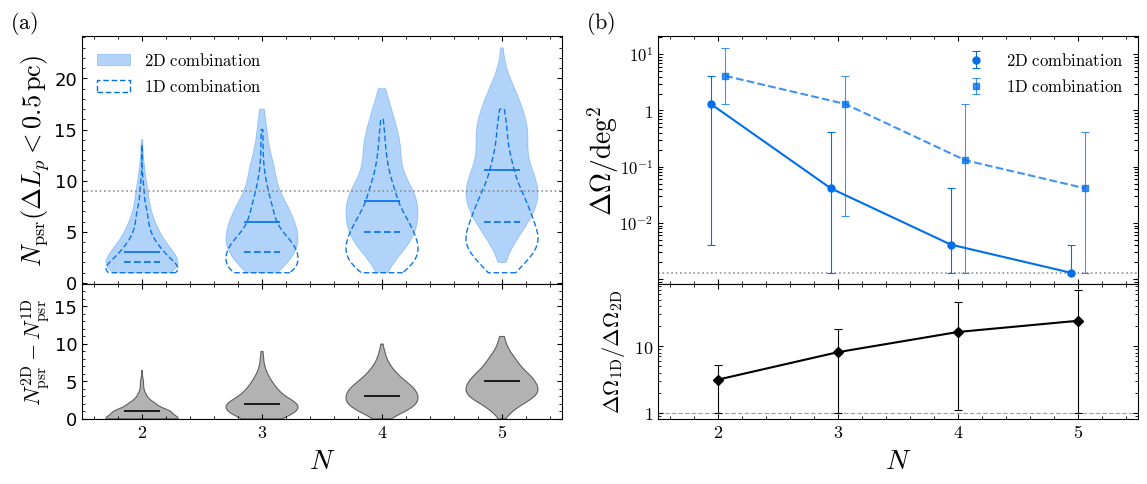

In [48]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.path import Path as MPath
from matplotlib.patches import Patch, PathPatch
from matplotlib.colors import to_rgba
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from scipy.stats import gaussian_kde

# ====== 全局设置 ======
mpl.rcParams.update({'patch.force_edgecolor': True, 'patch.antialiased': True})
plt.rcParams.update({
    'mathtext.fontset': 'cm', 'xtick.direction': 'in', 'ytick.direction': 'in',
    'font.size': 20, 'axes.labelsize': 20, 'xtick.labelsize': 13, 'ytick.labelsize': 13,
})

# ====== 常量 ======
FACE_COLOR    = '#006fed'
POSITIONS     = [1, 2, 3, 4]
XTICKS        = [1, 2, 3, 4]
XTLABELS      = [r'$2$', r'$3$', r'$4$', r'$5$']
S_LIST        = [2, 3, 4, 5]
SIGMA, TSPAN, DIST = "1e-07", 1, "1.0Gpc"
METHODS       = ["2d", "1d"]
FILE_SUFFIX   = ""
BAD_FLAG, RESULT_DIR = 100, "results"
DP_THRESH     = 0.5
FULL_SKY_DEG2 = 4 * np.pi * (180 / np.pi) ** 2
SNR, DIFF_LIMIT = 10, 9
OMEGA_0       = 0.001 * FULL_SKY_DEG2
OMEGA_DIFF    = ((1.0 / 160.0 / SNR) * (180 / np.pi)) ** 2
EXCLUDE_REALS = {}
THRESH_TAG    = "05pc"
BW_METHOD, N_KDE_SAMP = 0.3, 100_000


# ====== 工具函数 ======
def clip_violin_path(path, data, low_pct=0.0, high_pct=100.0):
    verts = path.vertices.copy()
    codes = path.codes.copy() if path.codes is not None else None
    verts[:, 1] = np.clip(verts[:, 1], np.percentile(data, low_pct), np.percentile(data, high_pct))
    return MPath(verts, codes)


def draw_violin(ax, data_list, positions, face_color, filled=True, low_pct=0.1, high_pct=99.75,
                alpha_fill=0.30, alpha_edge=0.30, lw=0.6, linestyle='-', bw=0.25, widths=0.6):
    vp = ax.violinplot(data_list, positions=positions, showmeans=False, showextrema=False, showmedians=True, widths=widths, bw_method=bw)
    for body, data in zip(vp['bodies'], data_list):
        raw, z = body.get_paths()[0], body.get_zorder()
        clip = clip_violin_path(raw, data, low_pct, high_pct)
        if filled:
            ax.add_patch(PathPatch(clip, facecolor=face_color, edgecolor='none', lw=0, alpha=alpha_fill, zorder=z))
        ax.add_patch(PathPatch(clip, facecolor='none', edgecolor=face_color, lw=lw, alpha=alpha_edge, linestyle=linestyle, zorder=z + 1))
        body.remove()
    if 'cmedians' in vp:
        vp['cmedians'].set_edgecolor(face_color)
        vp['cmedians'].set_linewidth(1.2)
        if linestyle != '-':
            vp['cmedians'].set_linestyle(linestyle)
    return vp


def hdi(data, cred_mass=0.68):
    s = np.sort(np.asarray(data))
    n = len(s)
    k = int(np.floor(cred_mass * n))
    if n - k <= 0:
        return s[0], s[-1]
    w = s[k:] - s[:n - k]
    i = np.argmin(w)
    return s[i], s[i + k]


def npsr_to_sky_deg2(n_psr):
    n_eff = np.minimum(np.asarray(n_psr, dtype=float), DIFF_LIMIT)
    return np.clip(OMEGA_0 * (1.0 / SNR) ** (n_eff / 2.0), OMEGA_DIFF, OMEGA_0)


# ====== 数据加载 ======
def load_count_per_real(s, method):
    csv_path = Path(RESULT_DIR) / f"dp_all_pulsars_t{TSPAN}_{DIST}_{s}s_sigma_{SIGMA}_{method}{FILE_SUFFIX}.csv"
    df = pd.read_csv(csv_path)
    bad_reals = df.loc[df["dp"] == BAD_FLAG, "realization"].unique()
    df = df[~df["realization"].isin(bad_reals)].copy()
    all_zero = df.groupby("realization")["dp"].apply(lambda x: (x == 0.0).all())
    df = df[~df["realization"].isin(all_zero[all_zero].index)].copy()
    all_reals = sorted(df["realization"].unique())
    counts = df.loc[df["dp"] < DP_THRESH].groupby("realization")["pulsar_id"].nunique().reindex(all_reals, fill_value=0)
    counts = counts[counts > 0]
    # ← 删掉 EXCLUDE_REALS 相关的两行
    return counts



count_dict = {method: {s: load_count_per_real(s, method) for s in S_LIST} for method in METHODS}

# ====== 派生数据 ======
delta_dict = {}
for s in S_LIST:
    common = count_dict["2d"][s].index.intersection(count_dict["1d"][s].index)
    delta_dict[s] = (count_dict["2d"][s].loc[common] - count_dict["1d"][s].loc[common]).values

sky_dict = {method: {s: npsr_to_sky_deg2(count_dict[method][s].values) for s in S_LIST} for method in METHODS}

ratio_1d_2d = {}
for s in S_LIST:
    ser_2d = pd.Series(sky_dict["2d"][s], index=count_dict["2d"][s].index, name="sky_2d")
    ser_1d = pd.Series(sky_dict["1d"][s], index=count_dict["1d"][s].index, name="sky_1d")
    merged = pd.concat([ser_2d, ser_1d], axis=1).dropna()
    ratio_1d_2d[s] = (merged["sky_1d"] / merged["sky_2d"]).values


# ====== 绘图 ======
fig = plt.figure(figsize=(12.0, 4.5))
gs = GridSpec(2, 2, figure=fig, height_ratios=[5.5, 3.0], hspace=0, wspace=0.20, left=0.09, right=0.97, top=0.95, bottom=0.10)
ax_l, ax_r = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])
ax_dn, ax_ratio = fig.add_subplot(gs[1, 0], sharex=ax_l), fig.add_subplot(gs[1, 1], sharex=ax_r)

# ── (a) N_psr violin ──
draw_violin(ax_l, [count_dict["2d"][s].values for s in S_LIST], POSITIONS, FACE_COLOR, filled=True, alpha_fill=0.30, alpha_edge=0.30, lw=0.6, bw=0.35)
draw_violin(ax_l, [count_dict["1d"][s].values for s in S_LIST], POSITIONS, FACE_COLOR, filled=False, alpha_edge=0.95, lw=1.0, linestyle=(0, (4, 2)), bw=0.35)
ax_l.set_xlim(0.5, 4.5)
ax_l.set_ylabel(r"$N_{\rm psr}(\Delta L_p < 0.5\,\mathrm{pc})$", labelpad=1.5, fontsize=19)
ax_l.axhline(DIFF_LIMIT, color='gray', ls=':', lw=1.2, alpha=0.85, zorder=2)
ax_l.legend(handles=[
    Patch(facecolor=to_rgba(FACE_COLOR, 0.30), edgecolor=to_rgba(FACE_COLOR, 0.3), linewidth=0.6, label=r'$\mathrm{2D\ combination}$'),
    Patch(facecolor='none', edgecolor=FACE_COLOR, linewidth=1.0, linestyle=(0, (4, 2)), label=r'$\mathrm{1D\ combination}$'),
], loc='upper left', frameon=True, framealpha=0, fontsize=12)
ax_l.text(-0.15, 1, r'$\mathrm{(a)}$', transform=ax_l.transAxes, fontsize=16, fontweight='bold', ha='left', va='bottom')

# ── (b) Sky area median + 68% HDI ──
def log_fmt(val, pos):
    exp = int(np.round(np.log10(val)))
    return '' if exp == -3 else (r'$1$' if exp == 0 else r'$10^{%d}$' % exp)

OFFSET = 0.06
right_styles = {
    "2d": dict(color=FACE_COLOR, marker='o', ms=5, lw=1.5, ls='-',  alpha=1.0,  offset=-OFFSET, label=r'$\mathrm{2D\ combination}$'),
    "1d": dict(color=FACE_COLOR, marker='s', ms=5, lw=1.5, ls='--', alpha=0.75, offset=+OFFSET, label=r'$\mathrm{1D\ combination}$'),
}
for method, sty in right_styles.items():
    xs = [p + sty['offset'] for p in POSITIONS]
    ys = [np.median(sky_dict[method][s]) for s in S_LIST]
    hdis = [hdi(sky_dict[method][s]) for s in S_LIST]
    yerr_lo = [m - h[0] for m, h in zip(ys, hdis)]
    yerr_hi = [h[1] - m for m, h in zip(ys, hdis)]
    ax_r.plot(xs, ys, color=sty['color'], alpha=sty['alpha'], lw=sty['lw'], ls=sty['ls'], zorder=3)
    ax_r.errorbar(xs, ys, yerr=[yerr_lo, yerr_hi], fmt=sty['marker'], color=sty['color'], alpha=sty['alpha'],
                  ms=sty['ms'], capsize=3, capthick=0.8, elinewidth=0.8, lw=0, zorder=5, label=sty['label'])

ax_r.set_yscale('log')
ax_r.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(log_fmt))
ax_r.tick_params(axis='y', which='major', labelsize=12)
ax_r.tick_params(axis='y', which='minor', length=3, width=0.8)
ax_r.set_ylabel(r'$\Delta\Omega/\mathrm{deg}^2$', labelpad=-1.5)
ax_r.set_xlim(0.5, 4.5)
ax_r.axhline(OMEGA_DIFF, color='gray', ls=':', lw=1.2, alpha=0.85, zorder=2)
ax_r.legend(loc='upper right', frameon=True, framealpha=0, fontsize=12)
ax_r.text(-0.15, 1, r'$\mathrm{(b)}$', transform=ax_r.transAxes, fontsize=16, fontweight='bold', ha='left', va='bottom')

# ── 下左：ΔN violin ──
draw_violin(ax_dn, [delta_dict[s] for s in S_LIST], POSITIONS, 'k', filled=True, alpha_fill=0.30, alpha_edge=0.55, lw=0.8, bw=0.4)
ax_dn.axhline(0, color='gray', ls='--', lw=0.9, alpha=0.7, zorder=0)
ax_dn.set_xticks(XTICKS)
ax_dn.set_xticklabels(XTLABELS)
ax_dn.set_xlabel(r"$N$", labelpad=3)
ax_dn.set_ylim(0, 18)
ax_dn.yaxis.set_major_locator(MultipleLocator(5))
ax_dn.set_ylabel(r"$N_{\rm psr}^{\rm 2D} - N_{\rm psr}^{\rm 1D}$", labelpad=1.5, fontsize=16)

# ── 下右：ΔΩ ratio (KDE in log10) ──
ys, yerr_lo, yerr_hi = [], [], []
for s in S_LIST:
    log_r = np.log10(ratio_1d_2d[s][ratio_1d_2d[s] >= 1])
    kde_samples = gaussian_kde(log_r, bw_method=BW_METHOD).resample(N_KDE_SAMP).flatten()
    kde_samples = kde_samples[kde_samples >= 0]
    med_log = np.median(kde_samples)
    lo_log, hi_log = hdi(kde_samples, cred_mass=0.68)
    lo_log = max(lo_log, 0.0)
    ys.append(10 ** med_log)
    yerr_lo.append(10 ** med_log - 10 ** lo_log)
    yerr_hi.append(10 ** hi_log - 10 ** med_log)

ax_ratio.plot(POSITIONS, ys, color='k', lw=1.5, zorder=3)
ax_ratio.errorbar(POSITIONS, ys, yerr=[yerr_lo, yerr_hi], fmt='D', color='k', ms=5, capsize=3, capthick=0.8, elinewidth=0.8, lw=0, zorder=5)
ax_ratio.axhline(1.0, color='gray', ls='--', lw=0.9, alpha=0.7, zorder=0)
ax_ratio.set_yscale('log')
ax_ratio.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, numticks=6))
ax_ratio.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f'${v:g}$'))
ax_ratio.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=20))
ax_ratio.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax_ratio.set_xticks(XTICKS)
ax_ratio.set_xticklabels(XTLABELS)
ax_ratio.set_xlabel(r"$N$", labelpad=3)
ax_ratio.set_ylabel(r"$\Delta\Omega_{\rm 1D}/\Delta\Omega_{\rm 2D}$", labelpad=5, fontsize=16)

fig.savefig(Path(RESULT_DIR) / "figS7.pdf", dpi=300, bbox_inches='tight')
plt.show()
